In [ ]:
# import os 
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import powerlaw as pwl
# from myutils.utilities import *
# import pycop

# from local_utils import *


In [ ]:

# fig_path = '/home/claudio/papers/adtxns_paper/code/test_final_figures'

# testing = False

In [ ]:
# txns_fn = '/home/claudio/tesi/sarafu/final_data/00_tx_with_bal_bwd_allpositivebalances.csv'
# TXDF = pd.read_csv(txns_fn,sep=",",header=0,dtype={'id': 'int',
#                                                     'date': 'string',
#                                                     'type': 'category',
#                                                     'source_xdai': 'string',
#                                                     'target_xdai': 'string',
#                                                     'weight': 'float',
#                                                     'source_bal_pre': 'float',
#                                                     'source_bal_post': 'float',
#                                                     'target_bal_pre': 'float',
#                                                     'target_bal_post': 'float',
#                                                     'source': 'int',
#                                                     'target': 'int',
#                                                     'source_role': 'category',
#                                                     'target_role': 'category',
#                                                     'right_weight': 'bool',
#                                                     'frac_out': 'float',
#                                                     'frac_in': 'float',
#                                                     'frac_out_post': 'float',
#                                                     'frac_in_post': 'float'}
#  )

# users_fn = '/home/claudio/tesi/sarafu/final_data/03_users_adjusted_allpositivebalances.csv'
# USERS = pd.read_csv(users_fn,  # assuming 'user_fn' is your file name
#                       sep=",",
#                       header=0,
#                       dtype={'id': 'int',
#                              'start': 'string',
#                              'final_bal': 'float',
#                              'gender': 'category',
#                              'area_name': 'string',
#                              'area_type': 'category',
#                              'role': 'category',
#                              'business': 'category',
#                              'poa': 'string',
#                              'xdai': 'string',
#                              'ovol_in': 'float',
#                              'ovol_out': 'float',
#                              'otxns_in': 'int',
#                              'otxns_out': 'int',
#                              'ounique_in': 'int',
#                              'ounique_out': 'int',
#                              'svol_in': 'float',
#                              'svol_out': 'float',
#                              'stxns_in': 'int',
#                              'stxns_out': 'int',
#                              'sunique_in': 'int',
#                              'sunique_out': 'int',
#                              'crid': 'int',
#                              'net': 'float',
#                              'initial_bal': 'float',
#                              'min_bal': 'float'}) 

# TXDF.drop(columns=['Unnamed: 0'],inplace=True)
# USERS.drop(columns=['Unnamed: 0'],inplace=True)

# formats = ['%Y-%m-%d %H:%M:%S.%f', '%Y-%m-%d %H:%M:%S', '%Y-%m-%d']
# for fmt in formats:
#     USERS.start = pd.to_datetime(USERS.start, format=fmt, errors='coerce').fillna(USERS.start)
# USERS = USERS.sort_values(by='start')

# for fmt in formats:
#     TXDF.date = pd.to_datetime(TXDF.date, format=fmt, errors='coerce').fillna(TXDF.date)
# TXDF = TXDF.sort_values(by='date')

# # Define the precision
# PRECISION = 3

# # Identify columns to exclude (those starting with "frac_")
# columns_to_exclude = TXDF.filter(like="frac_").columns

# # Identify columns to round (all except those starting with "frac_")
# columns_to_round = TXDF.columns.difference(columns_to_exclude)

# # Apply rounding only to the selected columns in TXDF
# TXDF[columns_to_round] = round_df(TXDF[columns_to_round], PRECISION)

# # Apply rounding to all columns in USERS
# USERS = round_df(USERS, PRECISION)


In [1]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
from pathlib import Path

In [ ]:
plt.rcParams.update({"text.usetex": True})
plt.rcParams["font.family"] = 'STIXGeneral'
plt.rc('font', size=22)          # controls default text sizes
plt.rc('axes', titlesize=14)     # fontsize of the axes title
plt.rc('axes', labelsize=22)     # fontsize of the x and y labels
plt.rc('xtick', labelsize=22)    # fontsize of the tick labels
plt.rc('ytick', labelsize=22)    # fontsize of the tick labels
plt.rc('legend', fontsize=22)    # legend fontsize
plt.rc('figure', titlesize=14)   # fontsize of the figure title

In [3]:
BATCH = "008"
# Use .expanduser() to turn "~" into "/home/yourusername"
PICKLED = Path("~/papers/adtxns_paper/pickled_data").expanduser()
SARAFU_PICKLED = PICKLED / "sarafu"

FIGURES = Path("~/papers/adtxns_paper/figures/thesis").expanduser()

In [4]:
TXDF = pickle.load(open(SARAFU_PICKLED / f"tx.pkl", "rb"))
USERS = pickle.load(open(SARAFU_PICKLED / f"users.pkl", "rb"))

In [4]:
END = pd.to_datetime(TXDF.date.max())
START = pd.to_datetime(TXDF.date.min())
NUM_PERIODS = 20
BAD_USERS = [8356,8357,21712,54998]


In [ ]:
# standard_tx = lambda tx: tx.type == 'STANDARD'
# good_users = lambda tx: ~tx.source.isin(BAD_USERS) | ~tx.target.isin(BAD_USERS)
# std_roles = lambda tx: tx.source_role.isin(['BENEFICIARY','GROUP_ACCOUNT','VENDOR']) & tx.target_role.isin(['BENEFICIARY','GROUP_ACCOUNT','VENDOR'])   
# standard = lambda tx: standard_tx(tx) & good_users(tx) & std_roles(tx)

# standard_users = lambda usr : usr.role.isin(['BENEFICIARY','GROUP_ACCOUNT','VENDOR'])
# validated = lambda usr: ~usr.crid.isin(BAD_USERS)


# disbursement = lambda tx: tx.type == 'DISBURSEMENT'
# withdrawal = lambda tx: tx.type.isin(['RECLAMATION','AGENT_OUT'])

# from_kinango = lambda tx: tx.source_area == 'Kinango Kwale'
# to_kinango = lambda tx: tx.target_area == 'Kinango Kwale'
# just_kinango = lambda tx: from_kinango(tx) & to_kinango(tx) 

# from_mukuru = lambda tx: tx.source_area == 'Mukuru Nairobi'
# to_mukuru = lambda tx: tx.target_area == 'Mukuru Nairobi'
# just_mukuru = lambda tx: from_mukuru(tx) & to_mukuru(tx) 


# #BalanceS DFS FILTERS
# balxmin = lambda bal,feat,tau: bal[feat]>=tau
# balxinf = lambda bal,feat,tau: bal[feat]>tau
# balxmax = lambda bal,feat,tau: bal[feat]<=tau
# balxsup = lambda bal,feat,tau: bal[feat]<tau

# #AGENTS DFS FILTERS
# agxmin = lambda ag,feat,tau: ag[feat]>=tau
# agxinf = lambda ag,feat,tau: ag[feat]>tau
# agxmax = lambda ag,feat,tau: ag[feat]<=tau
# agxsup = lambda ag,feat,tau: ag[feat]<tau

# Filtering section

In [5]:
txdf = TXDF.copy(deep=True)

In [6]:
tx = txdf[(txdf["type"] == "STANDARD") & #keeping just standard transactions
         #   (txdf["weight"] >= 1.0) & #keeping just transactions with weight >= 1.0
           (txdf["source_role"].isin(["BENEFICIARY", "GROUP_ACCOUNT", "VENDOR"])) & #keeping transactions made by these type of users
           (txdf["target_role"].isin(["BENEFICIARY", "GROUP_ACCOUNT", "VENDOR"]))  #keeping transactions received by these type of users
        ]


In [7]:
for w in [1,5,10,25,50]:
    print(round(txdf[txdf.weight < w].shape[0] / txdf.shape[0],3))

0.01
0.149
0.179
0.329
0.428


In [8]:
print("Unique sources in tx:", len(set(tx['source'])))
print("Unique targets in tx:", len(set(tx['target'])))
print("Users appearing in both:", len(set(tx['source']) & set(tx['target'])))


Unique sources in tx: 39194
Unique targets in tx: 25205
Users appearing in both: 23736


In [11]:
agents_outer = basic_agents(tx,USERS.copy(deep=True),how='outer') #create agent dataframe
 
agents_outer.select_dtypes(include=["number"]).min()

cond1 = agents_outer['tx_in'].sum() == agents_outer['tx_out'].sum()
cond2 = agents_outer['vol_in'].sum() == agents_outer['vol_out'].sum()



print(
    "This filtering conserves the number of transactions:\n"
    f"N^i = {abs(agents_outer['tx_in'].sum()):.2f}\n"
    f"N^o = {abs(agents_outer['tx_out'].sum()):.2f}\n"
    if cond1 else
    "This filtering doesn't conserve the number of transactions:\n"
    f"N^i = {abs(agents_outer['tx_in'].sum()):.2f}\n"
    f"N^o = {abs(agents_outer['tx_out'].sum()):.2f}\n"
)



print(
    "This filtering conserves the total volume:\n"
    f"V^i = {abs(agents_outer['vol_in'].sum()):.2f}\n"
    f"V^o = {abs(agents_outer['vol_out'].sum()):.2f}\n"
    if cond2 else
    "This filtering doesn't conserve the total volume:\n"
    f"V^i = {abs(agents_outer['vol_in'].sum()):.2f}\n"
    f"V^o = {abs(agents_outer['vol_out'].sum()):.2f}\n"
    f"Volume difference: {abs(agents_outer['vol_in'].sum() - agents_outer['vol_out'].sum()):.2f}"
)



with open("sarafu_info.txt", 'a') as f:
    print(f'Agents are {len(agents_outer)/len(USERS)*100:.2f}% of all users',file=f)
    print(f'')
    print(
        "This filtering conserves the number of transactions:\n"
        f"N^i = {abs(agents_outer['tx_in'].sum()):.2f}\n"
        f"N^o = {abs(agents_outer['tx_out'].sum()):.2f}\n"
        if cond1 else
        "This filtering doesn't conserve the number of transactions:\n"
        f"N^i = {abs(agents_outer['tx_in'].sum()):.2f}\n"
        f"N^o = {abs(agents_outer['tx_out'].sum()):.2f}\n", 
        f"Txns difference: {abs(agents_outer['tx_in'].sum() - agents_outer['tx_out'].sum()):.2f}",

        file=f
    )



    print(
        "This filtering conserves the total volume:\n"
        f"V^i = {abs(agents_outer['vol_in'].sum()):.2f}\n"
        f"V^o = {abs(agents_outer['vol_out'].sum()):.2f}\n"
        if cond2 else
        "This filtering doesn't conserve the total volume:\n"
        f"V^i = {abs(agents_outer['vol_in'].sum()):.2f}\n"
        f"V^o = {abs(agents_outer['vol_out'].sum()):.2f}\n"
        f"Volume difference: {abs(agents_outer['vol_in'].sum() - agents_outer['vol_out'].sum()):.2f}",
        file=f
    )


This filtering conserves the number of transactions:
N^i = 422534.00
N^o = 422534.00

This filtering doesn't conserve the total volume:
V^i = 296963802.65
V^o = 296963802.65
Volume difference: 0.00



In [12]:
print(agents_outer.shape[0] / USERS.shape[0])
print(agents_outer[agents_outer.tx_in == 0].shape[0] / agents_outer.shape[0])
print(agents_outer[agents_outer.tx_out == 0].shape[0] / agents_outer.shape[0])
print(agents_outer[agents_outer.tx_in == 0].shape[0] / USERS.shape[0])
print(agents_outer[agents_outer.tx_out == 0].shape[0] / USERS.shape[0])

0.7396500291036089
0.3801490298305585
0.036126208100730396
0.28117724097788127
0.026720750873108264


In [13]:
agents = agents_outer[(agents_outer['tx_in'] > 0) & (agents_outer['tx_out'] > 0)]

print(agents.select_dtypes(include=["number"]).min())

cond1 = agents['tx_in'].sum() == agents['tx_out'].sum()
cond2 = agents['vol_in'].sum() == agents['vol_out'].sum()



print(
    "This filtering conserves the number of transactions:\n"
    f"N^i = {abs(agents['tx_in'].sum()):.2f}\n"
    f"N^o = {abs(agents['tx_out'].sum()):.2f}\n"
    if cond1 else
    "This filtering doesn't conserve the number of transactions:\n"
    f"N^i = {abs(agents['tx_in'].sum()):.2f}\n"
    f"N^o = {abs(agents['tx_out'].sum()):.2f}\n"
)



print(
    "This filtering conserves the total volume:\n"
    f"V^i = {abs(agents['vol_in'].sum()):.2f}\n"
    f"V^o = {abs(agents['vol_out'].sum()):.2f}\n"
    if cond2 else
    "This filtering doesn't conserve the total volume:\n"
    f"V^i = {abs(agents['vol_in'].sum()):.2f}\n"
    f"V^o = {abs(agents['vol_out'].sum()):.2f}\n"
    f"Volume difference: {abs(agents['vol_in'].sum() - agents['vol_out'].sum()):.2f}"
)



with open("sarafu_info.txt", 'a') as f:
    print(f'Agents are {len(agents)/len(USERS)*100:.2f}% of all users',file=f)
    print(f'')
    print(
        "This filtering conserves the number of transactions:\n"
        f"N^i = {abs(agents['tx_in'].sum()):.2f}\n"
        f"N^o = {abs(agents['tx_out'].sum()):.2f}\n"
        if cond1 else
        "This filtering doesn't conserve the number of transactions:\n"
        f"N^i = {abs(agents['tx_in'].sum()):.2f}\n"
        f"N^o = {abs(agents['tx_out'].sum()):.2f}\n", 
        f"Txns difference: {abs(agents['tx_in'].sum() - agents['tx_out'].sum()):.2f}",

        file=f
    )



    print(
        "This filtering conserves the total volume:\n"
        f"V^i = {abs(agents['vol_in'].sum()):.2f}\n"
        f"V^o = {abs(agents['vol_out'].sum()):.2f}\n"
        if cond2 else
        "This filtering doesn't conserve the total volume:\n"
        f"V^i = {abs(agents['vol_in'].sum()):.2f}\n"
        f"V^o = {abs(agents['vol_out'].sum()):.2f}\n"
        f"Volume difference: {abs(agents['vol_in'].sum() - agents['vol_out'].sum()):.2f}",
        file=f
    )


crid               1.000000e+00
tx_in              1.000000e+00
vol_in             1.900000e-01
mean_earn          1.900000e-01
median_earn        1.900000e-01
max_earn           1.900000e-01
min_earn           1.000000e-02
mean_frac_in       2.222222e-03
median_frac_in     2.112825e-04
max_frac_in        2.222222e-03
min_frac_in        5.642671e-07
in_deg             1.000000e+00
tx_out             1.000000e+00
vol_out            1.000000e+00
mean_exp           1.000000e+00
median_exp         1.000000e+00
max_exp            1.000000e+00
min_exp            1.000000e-02
mean_frac_out      9.250694e-04
median_frac_out    2.092488e-04
max_frac_out       9.250694e-04
min_frac_out       1.416792e-06
out_deg            1.000000e+00
dtype: float64
This filtering doesn't conserve the number of transactions:
N^i = 419040.00
N^o = 391253.00

This filtering doesn't conserve the total volume:
V^i = 296691269.52
V^o = 291571346.11
Volume difference: 5119923.41



In [14]:
filtered_crid = agents.crid.unique() 




In [15]:
tx = tx.loc[(tx.target.isin(filtered_crid))&(tx.source.isin(filtered_crid))]


In [ ]:
sarafu = pickle

In [ ]:
tx = 

# Preliminary analysis 

In [ ]:
import matplotlib as mpl
mpl.rcdefaults()

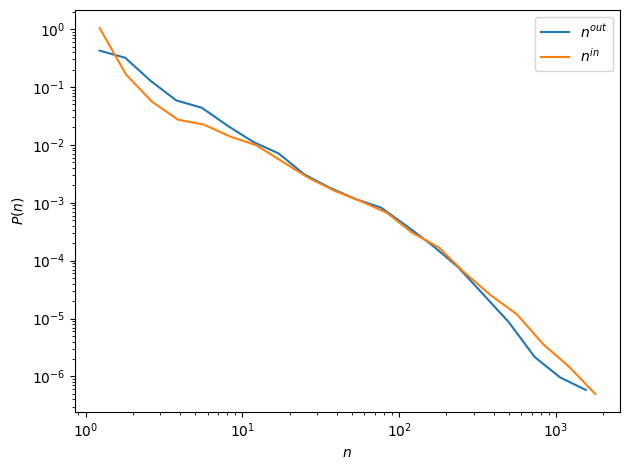

In [24]:
colors = ['tab:blue', 'tab:red']
markers = ['o', 's']
disc = False

columns = ['tx_out', 'tx_in']
labels = ['$n^{out}$', '$n^{in}$']

fig, ax = plt.subplots()

for idx, col in enumerate(columns):
    data = agents[col]
    # data = agents[col]/agents[col].sum()
    xmin_plot = data[data != 0].min()  # Start plot from same min
    xmax = data.max()

    h = histogram(data,num_bins=21)
    ax.plot(h[0],h[1],label=labels[idx])

# Legend and labels
ax.set_ylabel("$P(n)$")
ax.set_xlabel("$n$")

ax.set_xscale('log')
ax.set_yscale('log')
ax.legend()
# ax.grid(True)

plt.tight_layout()
plt.show()


# fig.savefig(f'{fig_path}/txintxout.png',bbox_inches='tight', pad_inches=0.1)
fig.savefig(f'{fig_path}/txintxout.png')


Error in callback <function _draw_all_if_interactive at 0x7f01ce82ae60> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

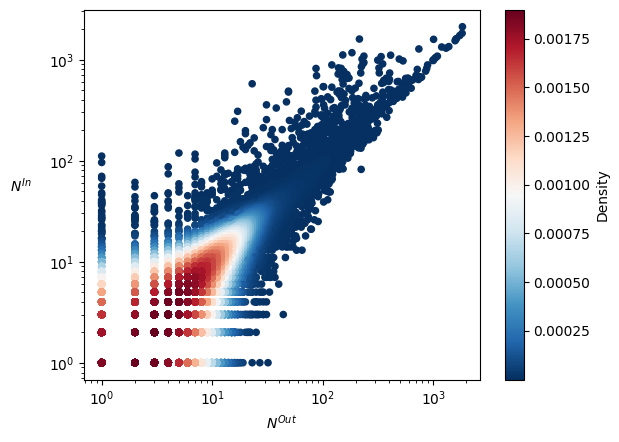

In [ ]:
data = agents[['tx_out','tx_in']].values
# agents['norm_tx_out'] = agents.tx_out/agents.tx_out.sum()
# agents['norm_tx_in'] = agents.tx_in/agents.tx_in.sum()
# data = agents[['norm_tx_out','norm_tx_in']].values

fig,ax=plt.subplots()
xlabel = r'$N^{out}$'
ylabel = r'$N^{in}$'

plot_scatter_kde(data,ax,cmap='RdBu_r',s=20)
plt.loglog()
plt.xlabel(xlabel.title())
plt.ylabel(ylabel.title(),rotation = 0,labelpad=20)
fig.savefig(f'{fig_path}/txintxout_corr.png')


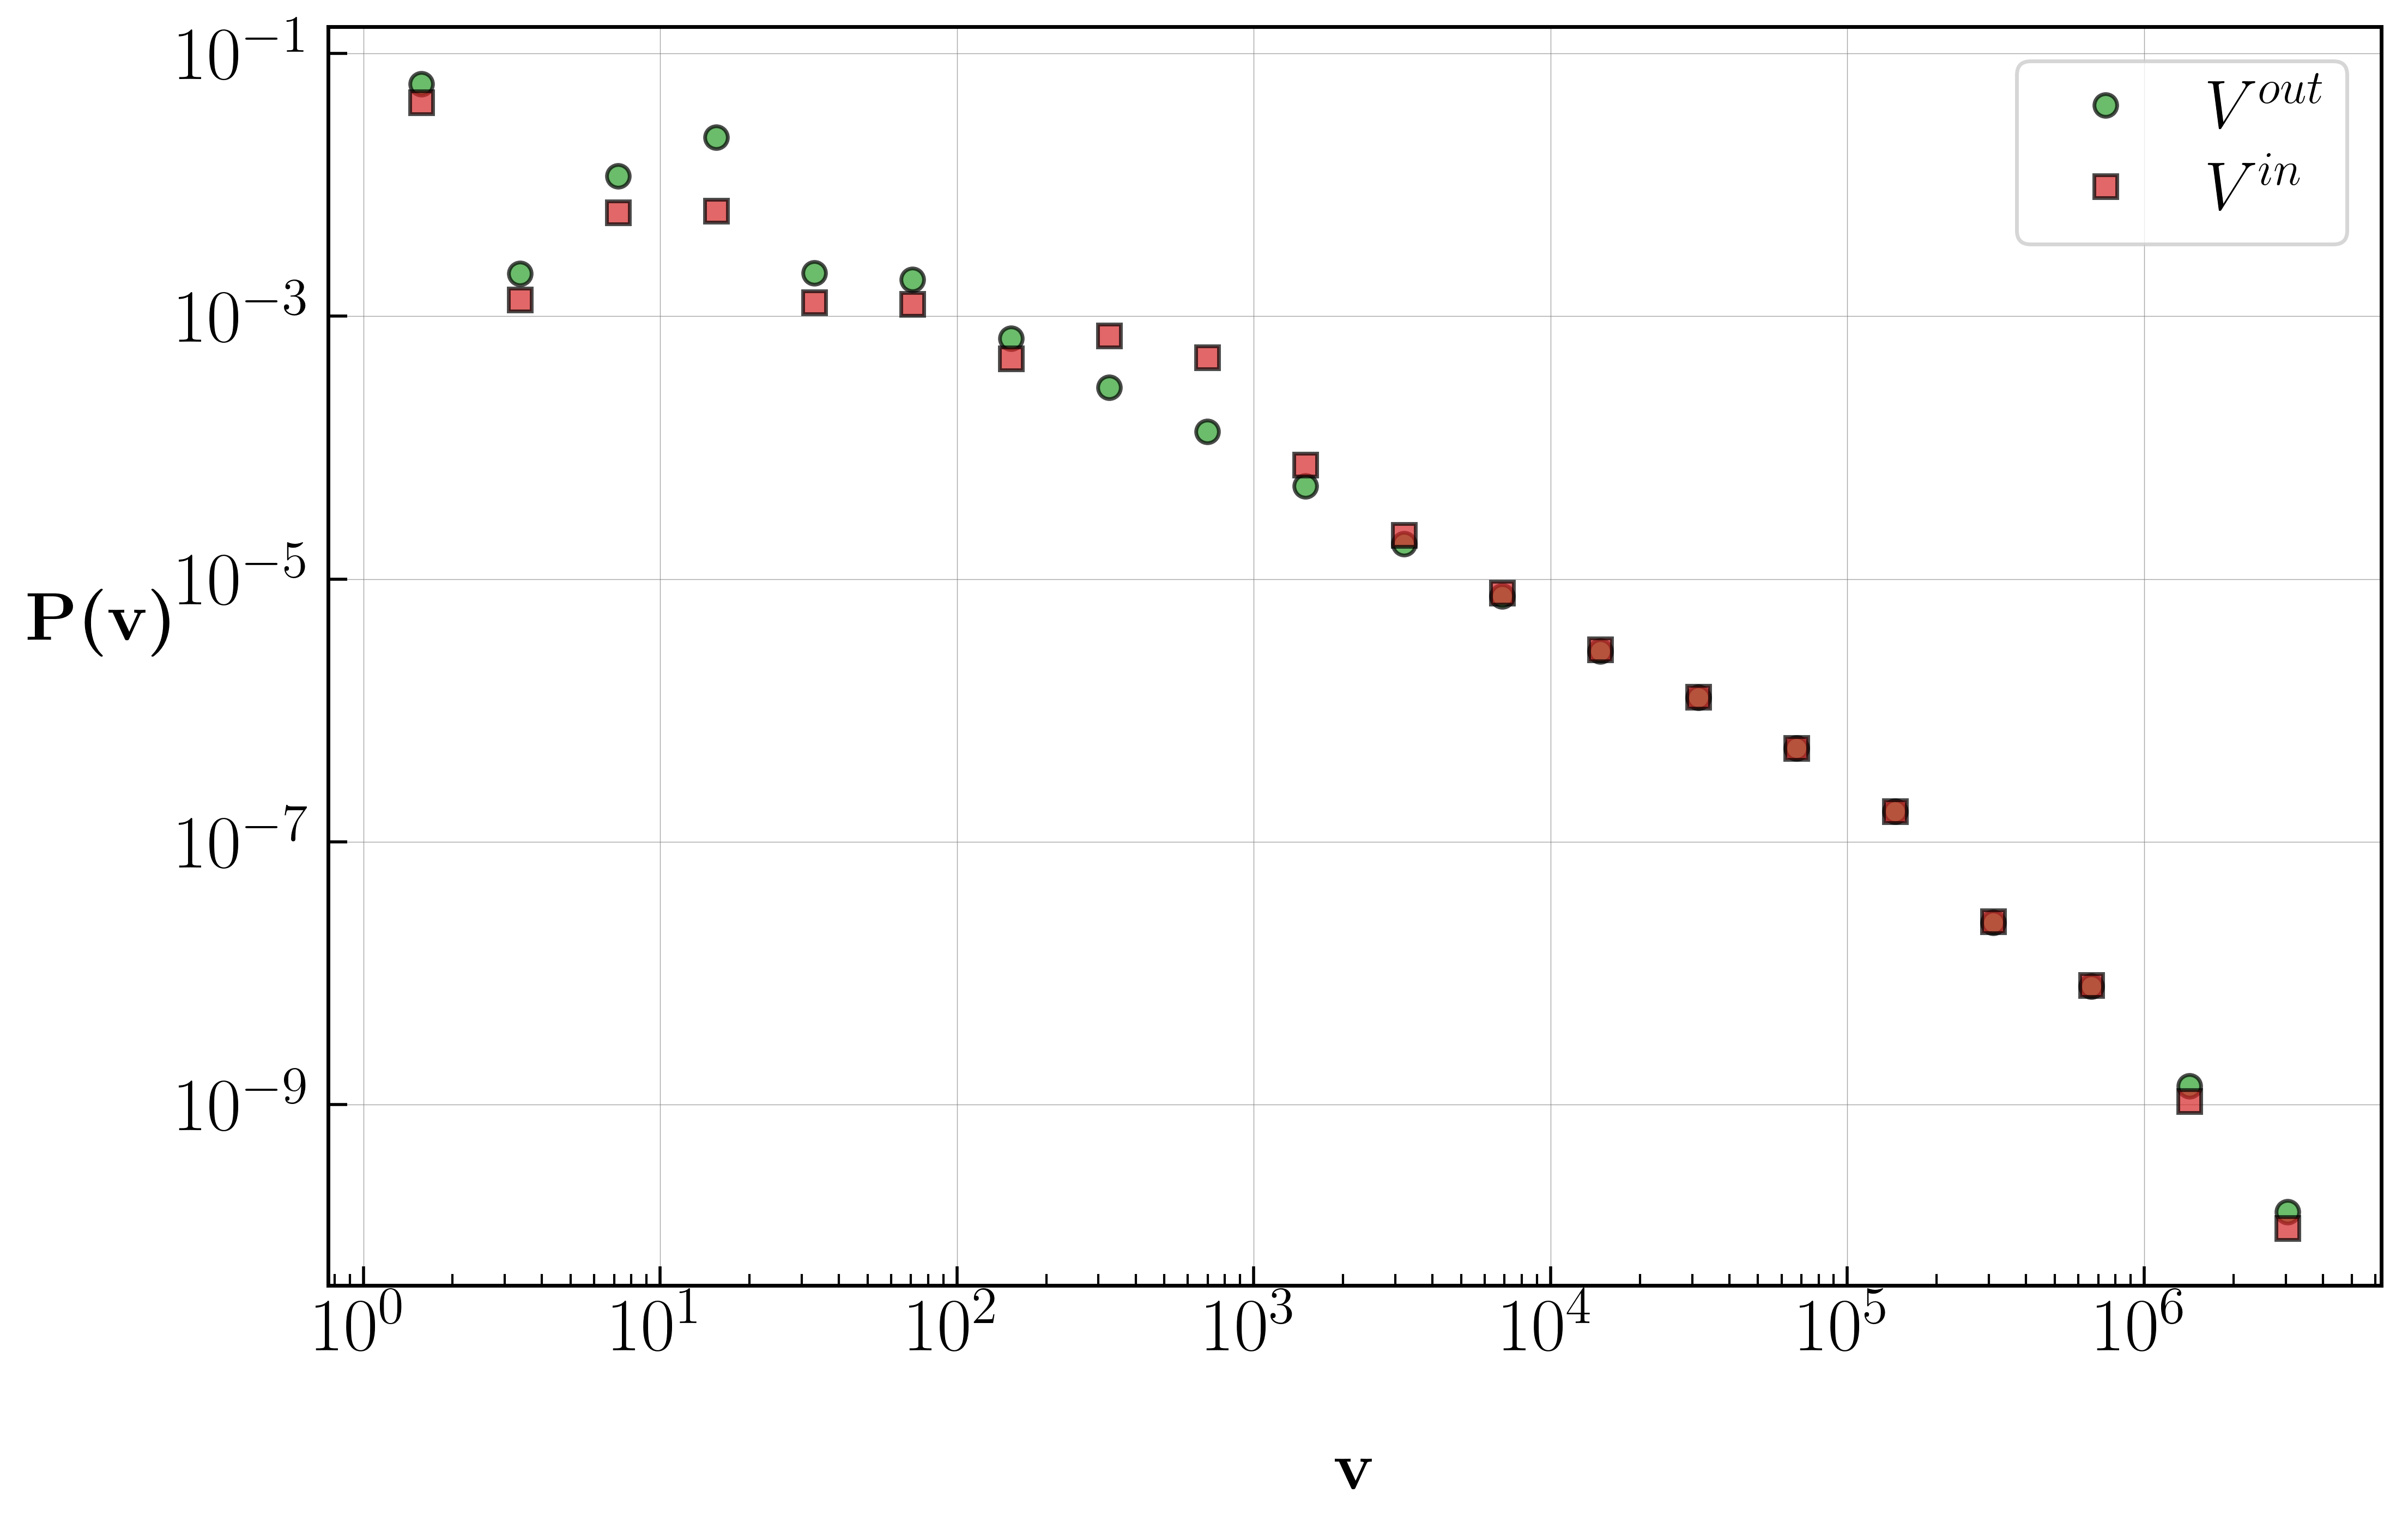

In [55]:
data = agents[['vol_out','vol_in']]

fig = plt.figure()
# ax=plt.gca()
xlabel = r'$V^{out}$'
ylabel = r'$V^{in}$'

plot_distribution(data.vol_in,ax=plt.gca(),color='tab:green',markeredgecolor='k',alpha = 0.7, linestyle='', marker='o',label = xlabel)
plot_distribution(data.vol_out,ax=plt.gca(),color='tab:red',markeredgecolor='k',alpha = 0.7, linestyle='', marker='s',label= ylabel)
plt.xlabel(r'$\textbf{v}$',rotation = 0,labelpad=20)
plt.ylabel(r'$\textbf{P(v)}$',rotation = 0,labelpad=20)
plt.legend()

In [56]:
# with open(f'{fig_path}/sarafu_info.txt', 'a') as f:
#     print(f'Volumes correlation {data.corr().values[0,1].round(3)}',file=f)

Text(0, 0.5, '$V^{In}$')

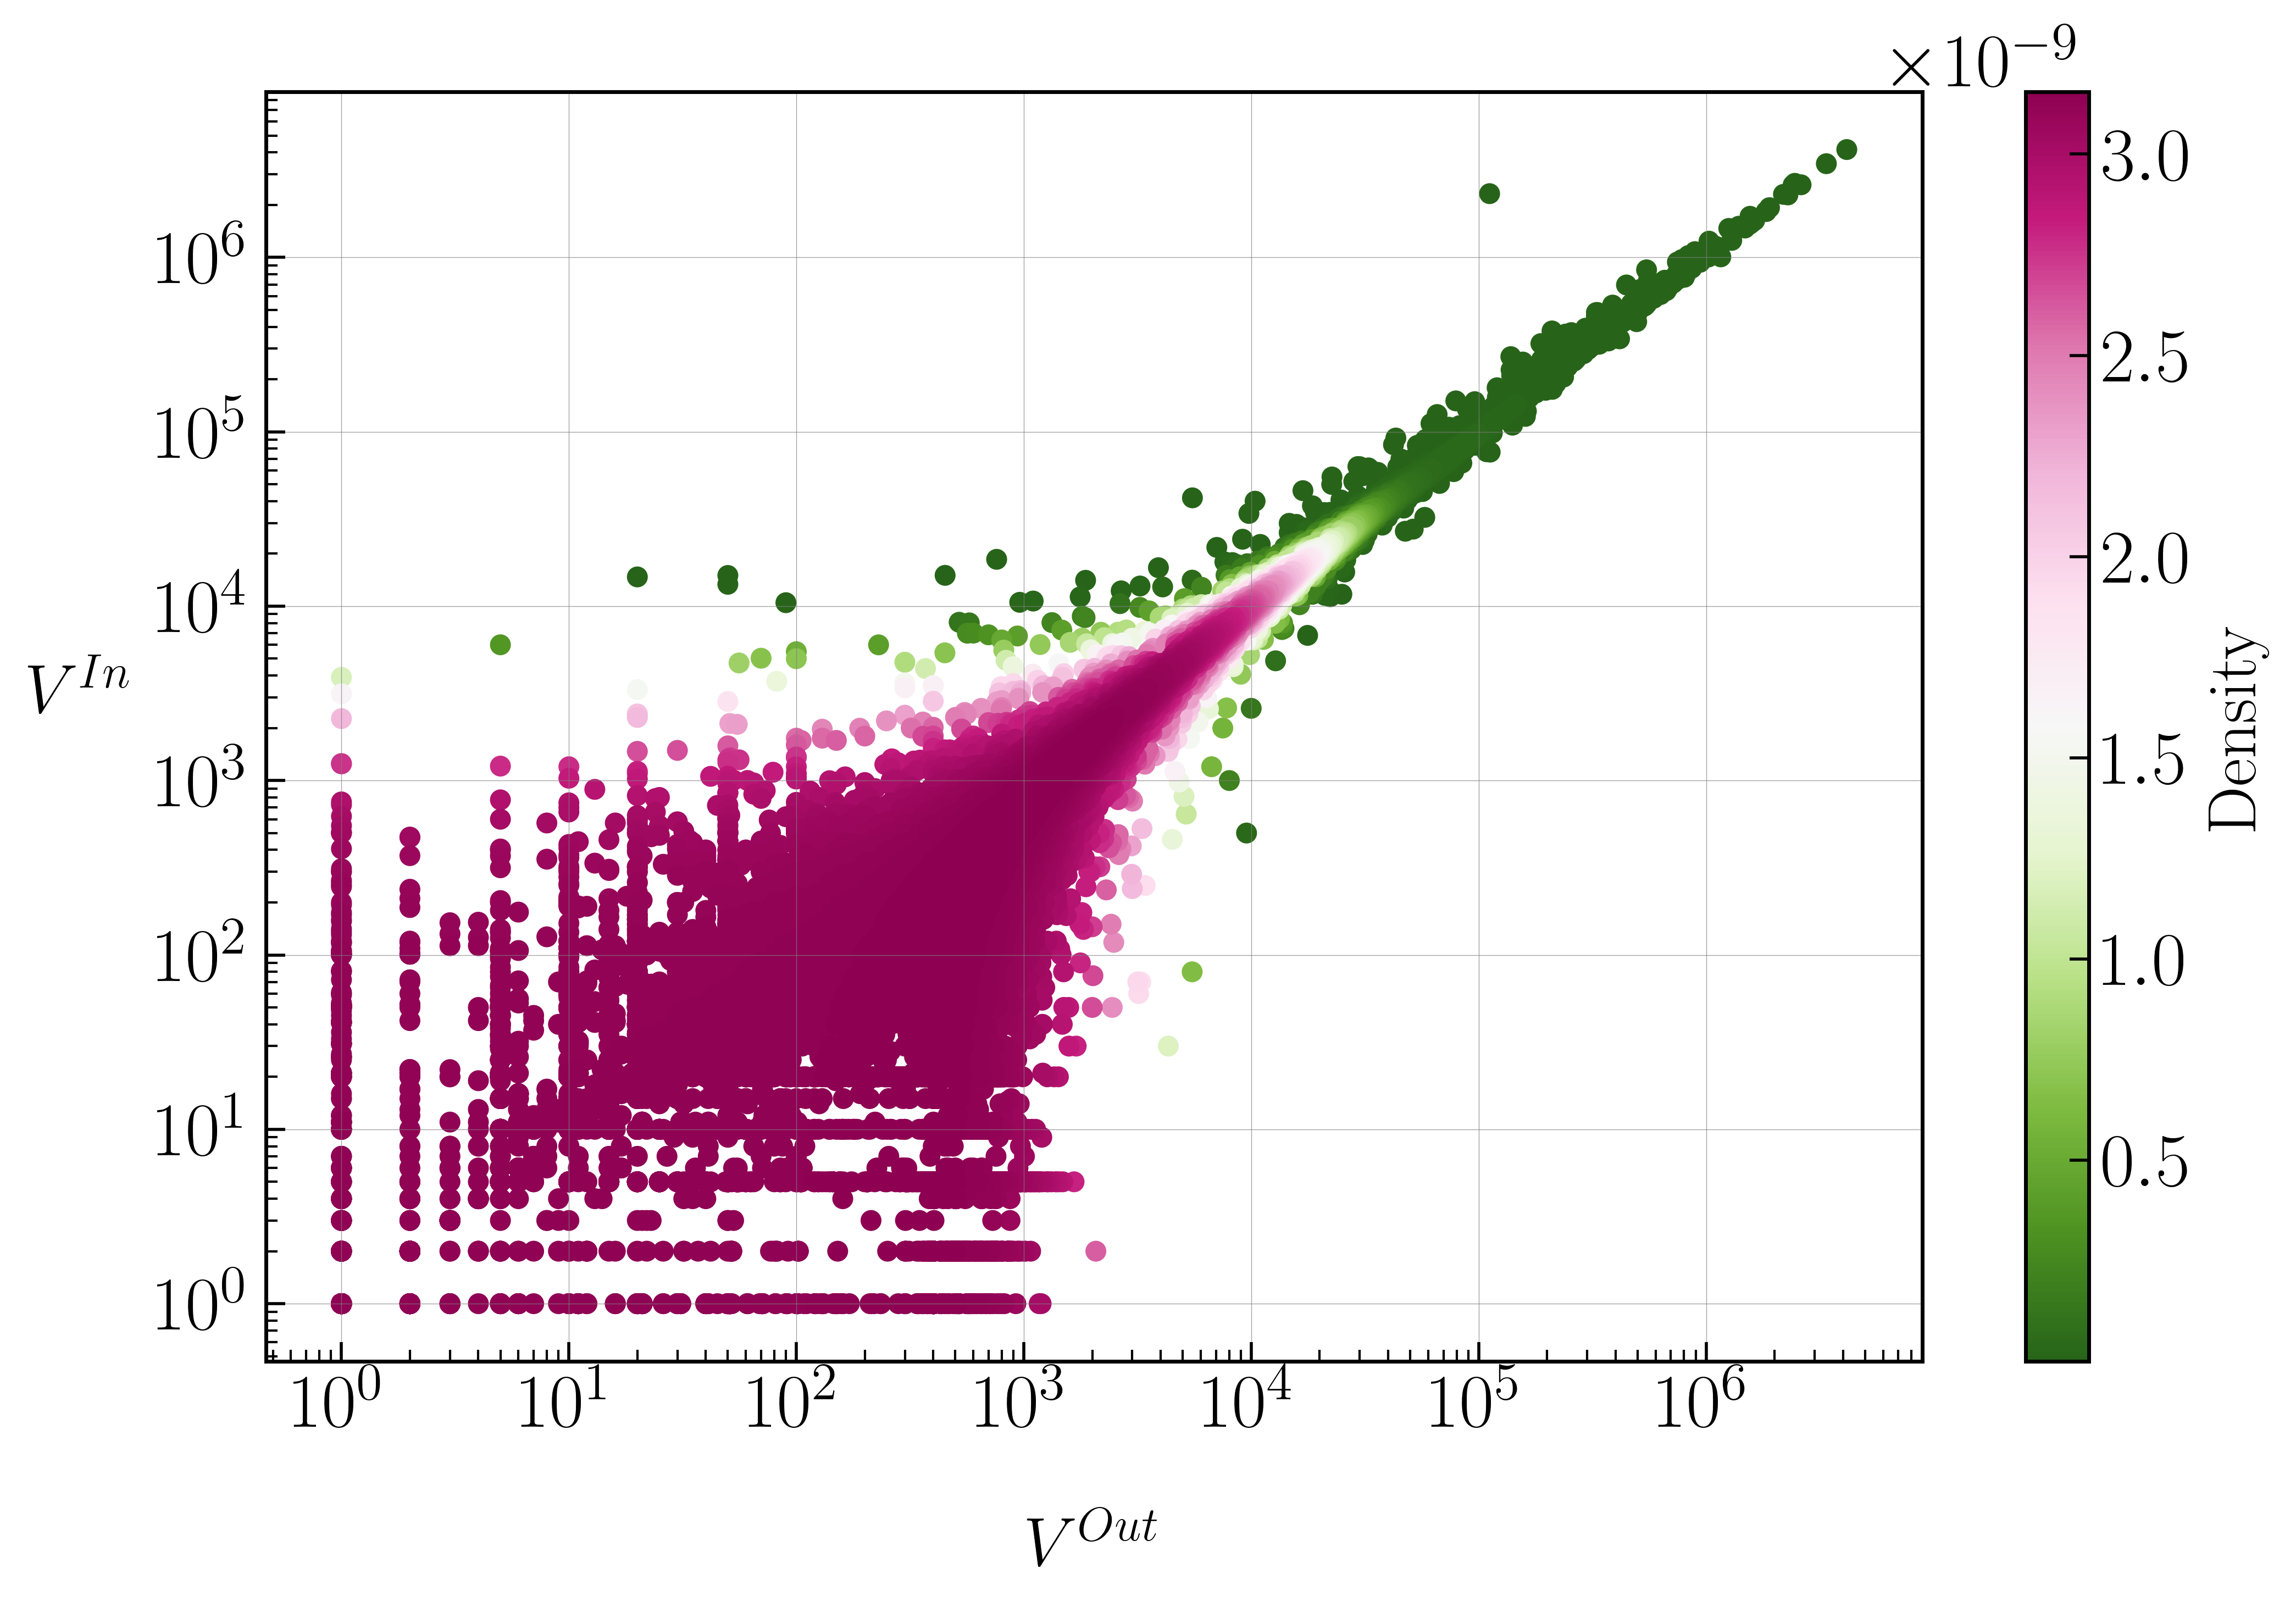

In [57]:
fig,ax=plt.subplots()
plot_scatter_kde(data.values,ax,cmap='PiYG_r',s=20)
plt.loglog()
plt.xlabel(xlabel.title(),rotation = 0,labelpad=20)
plt.ylabel(ylabel.title(),rotation = 0,labelpad=20)


In [ ]:
fig.savefig(f'{fig_path}/volinvoloutcorr.png',bbox_inches='tight', pad_inches=0.1)

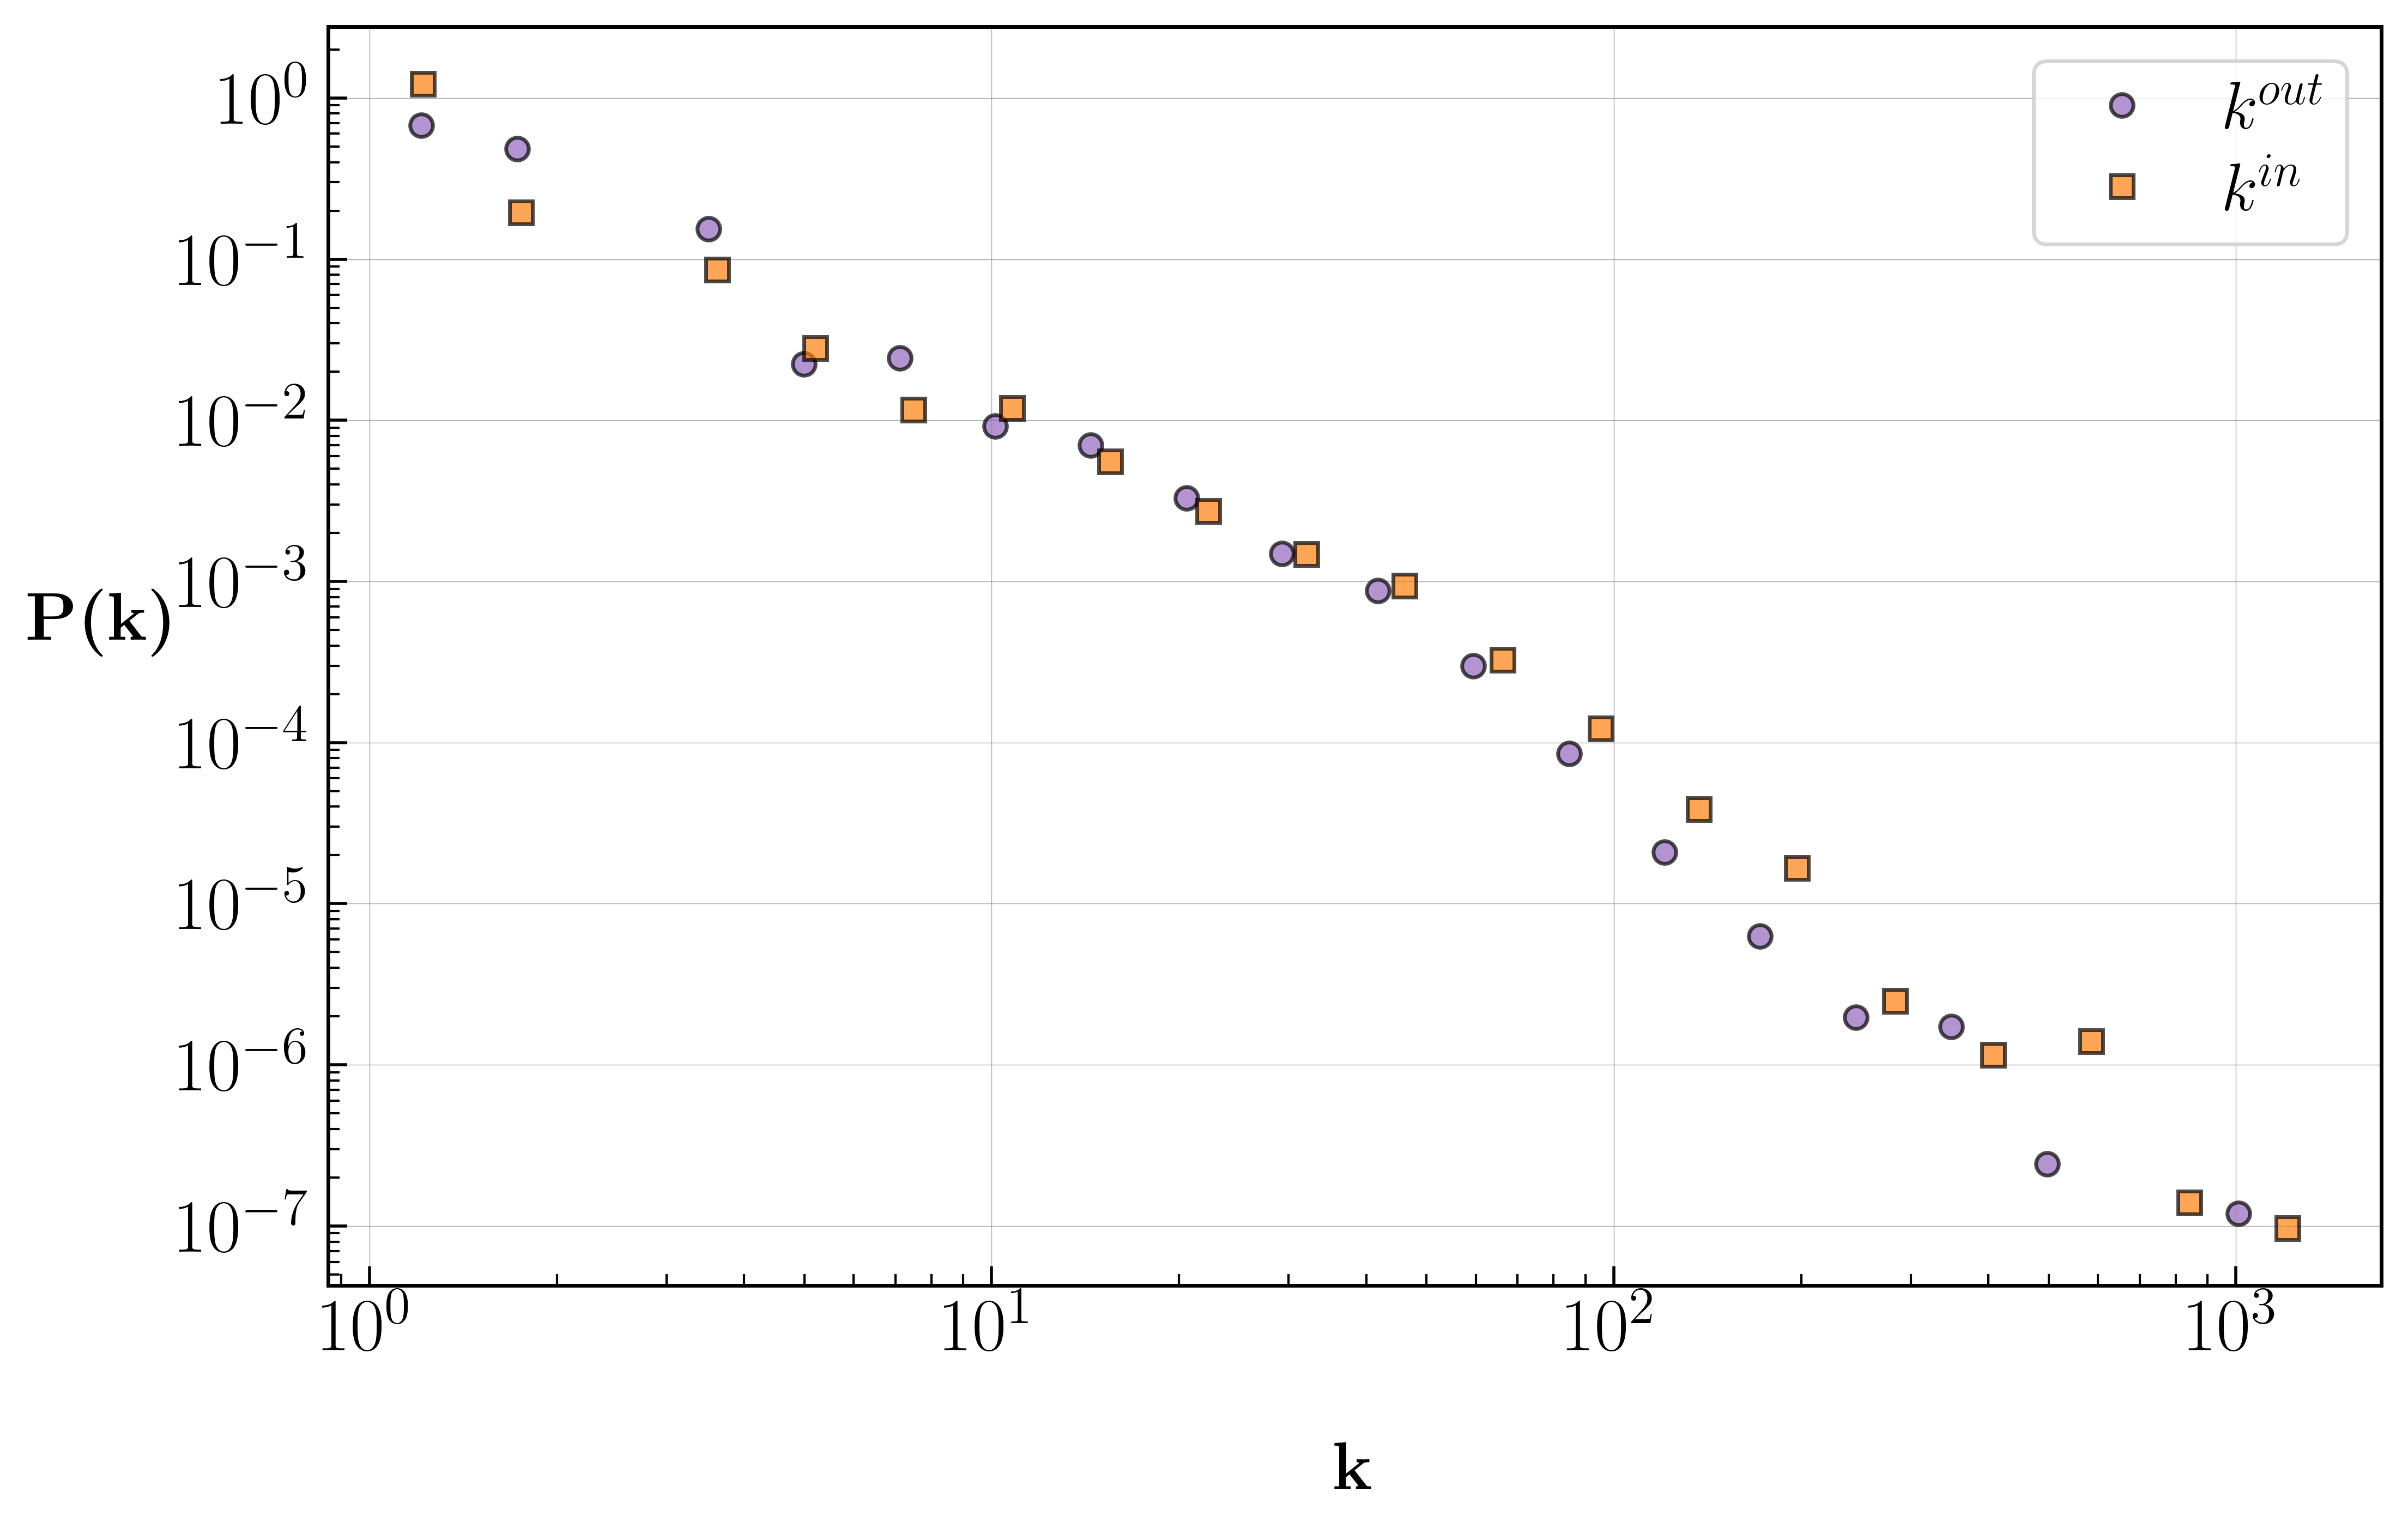

In [58]:
data = agents[['out_deg','in_deg']]

fig = plt.figure()
# ax=plt.gca()
xlabel = r'$k^{out}$'
ylabel = r'$k^{in}$'
colors = ['tab:purple', 'tab:orange']

plot_distribution(data.out_deg,ax=plt.gca(),color=colors[0],markeredgecolor='k',alpha = 0.7, linestyle='', marker='o',label = xlabel)
plot_distribution(data.in_deg,ax=plt.gca(),color=colors[1],markeredgecolor='k',alpha = 0.7, linestyle='', marker='s',label= ylabel)
plt.xlabel(r'$\textbf{k}$',rotation = 0,labelpad=20)
plt.ylabel(r'$\textbf{P(k)}$',rotation = 0, labelpad=20)
plt.legend()

In [ ]:
fig.savefig(f'{fig_path}/degindegout.png',bbox_inches='tight', pad_inches=0.1)

Text(0, 0.5, '$K^{In}$')

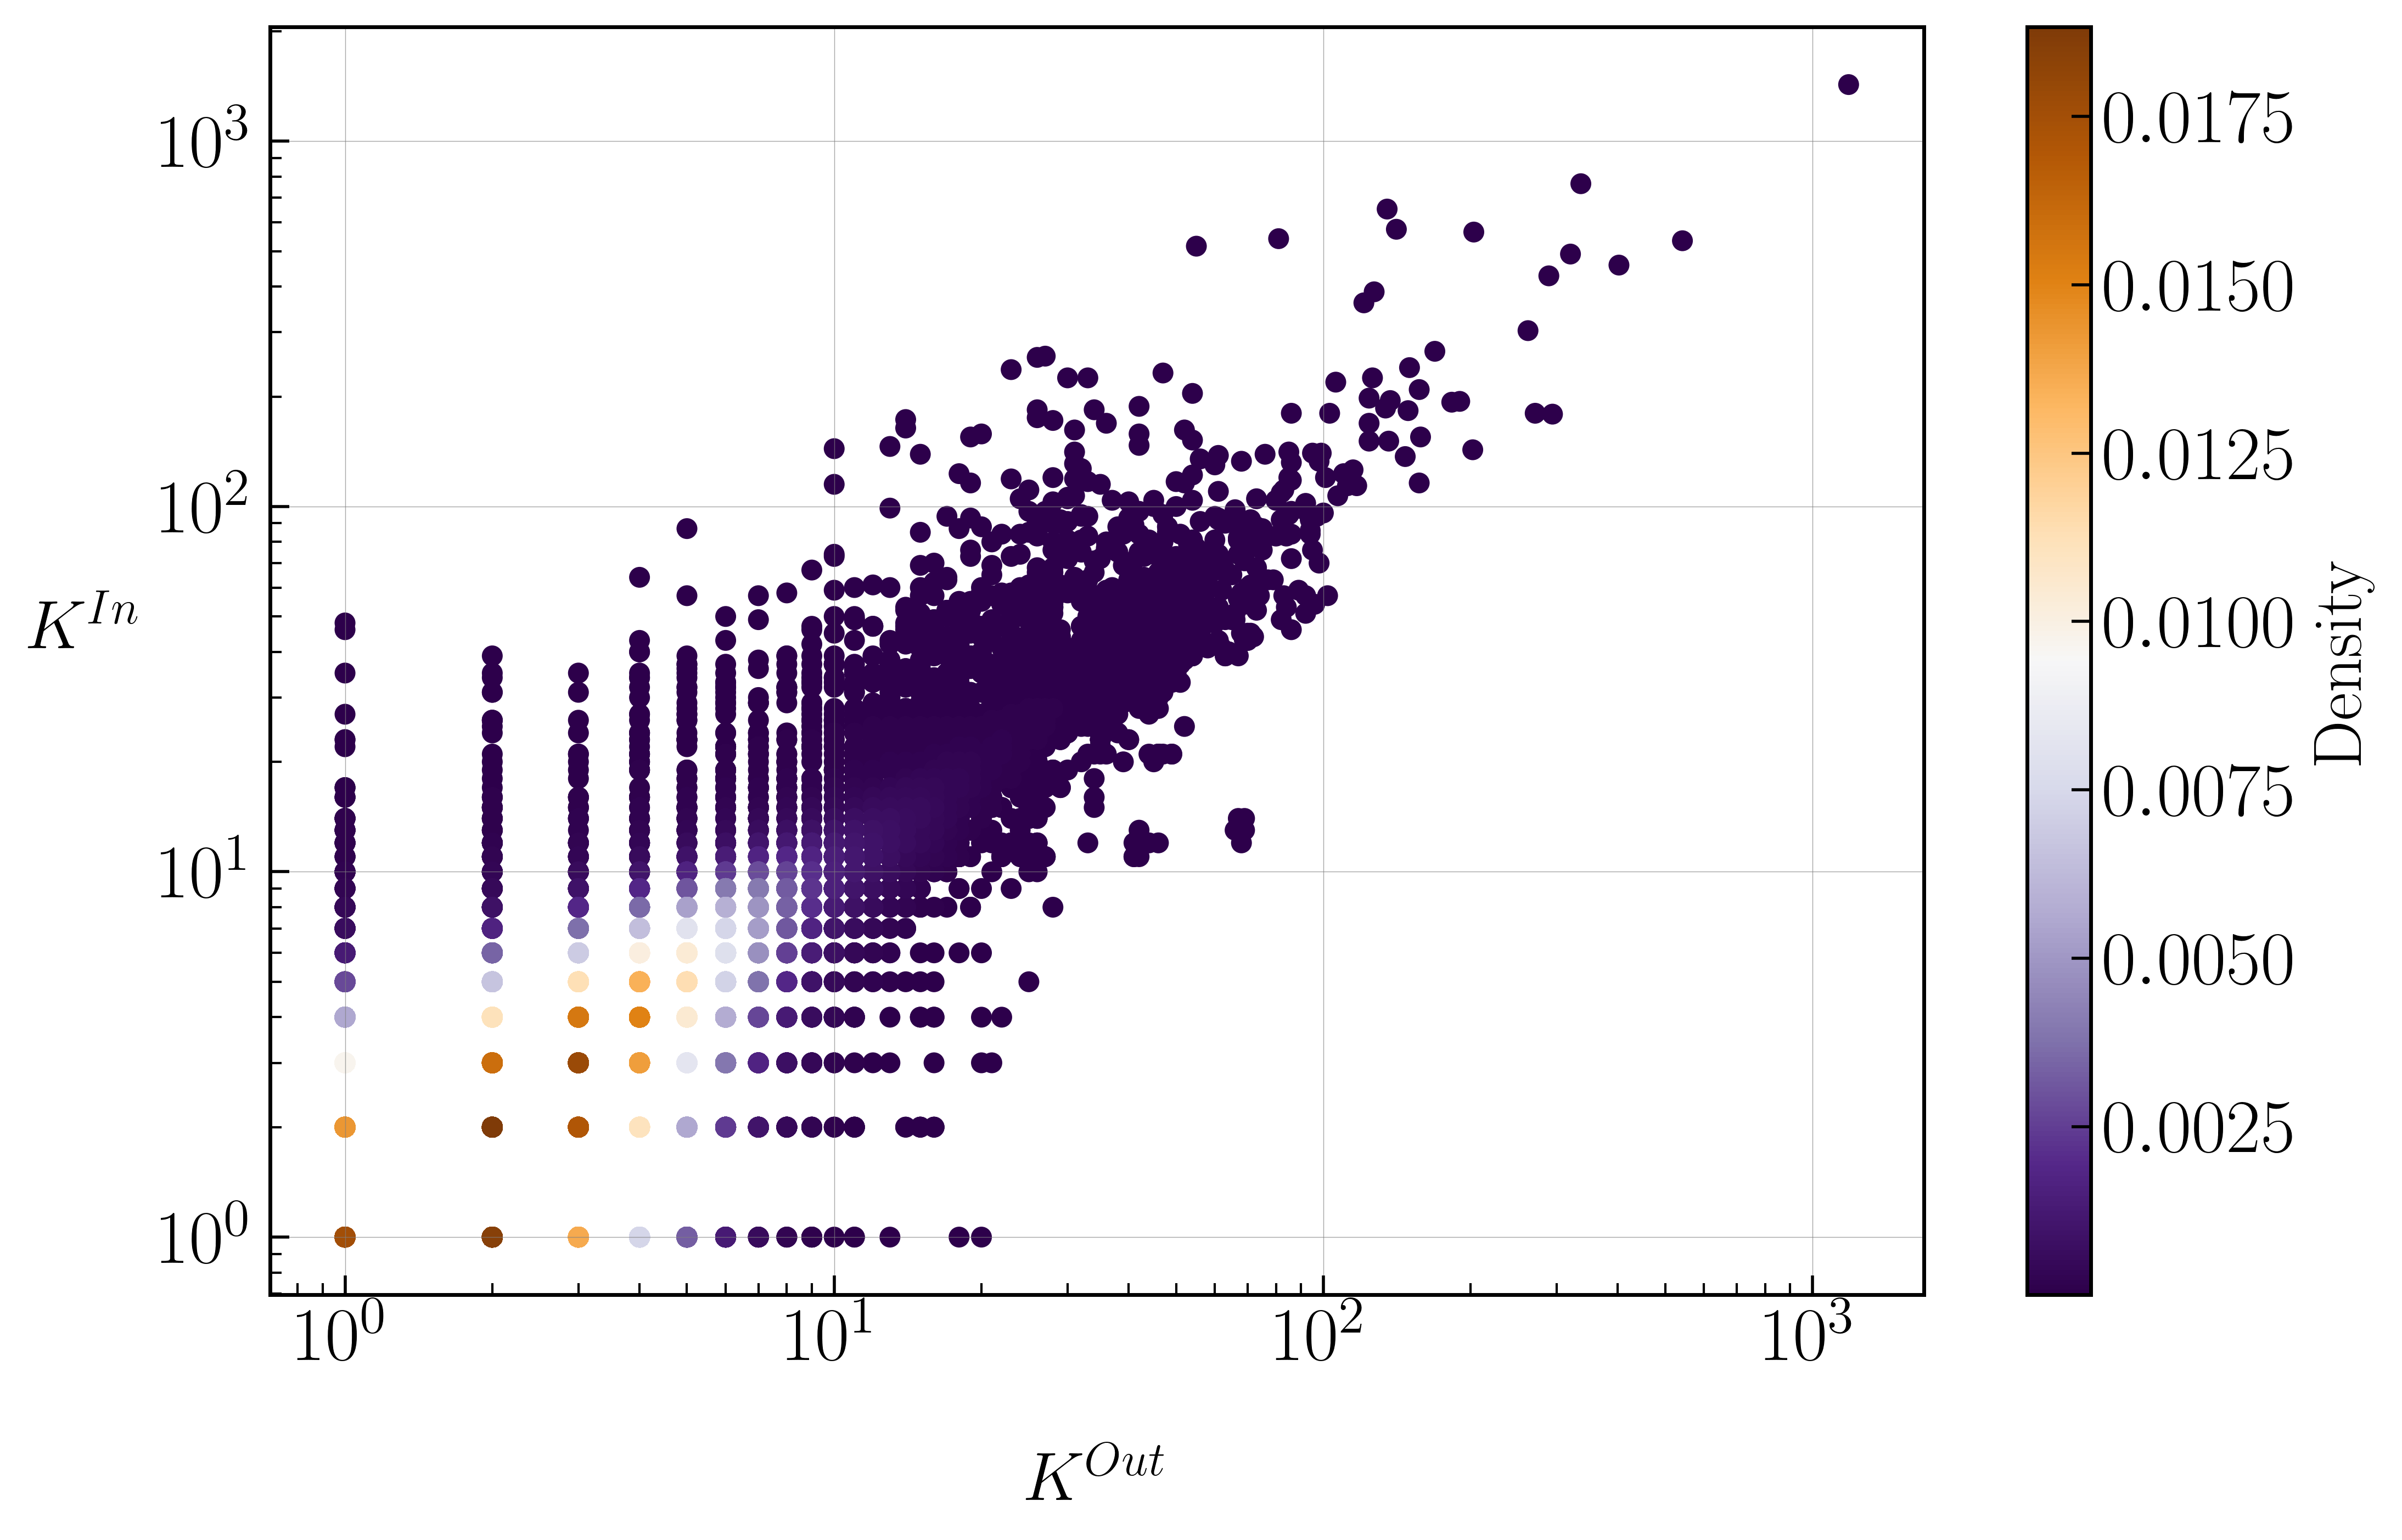

In [59]:
fig,ax=plt.subplots()
plot_scatter_kde(data.values,ax,cmap='PuOr_r',s=20)
plt.loglog()
plt.xlabel(xlabel.title(),rotation = 0,labelpad=20)
plt.ylabel(ylabel.title(),rotation = 0,labelpad=20)

In [ ]:
fig.savefig(f'{fig_path}/degindegoutcorr.png',bbox_inches='tight', pad_inches=0.1)

Text(0, 0.5, '$p(\\langle \\xi \\rangle)$')

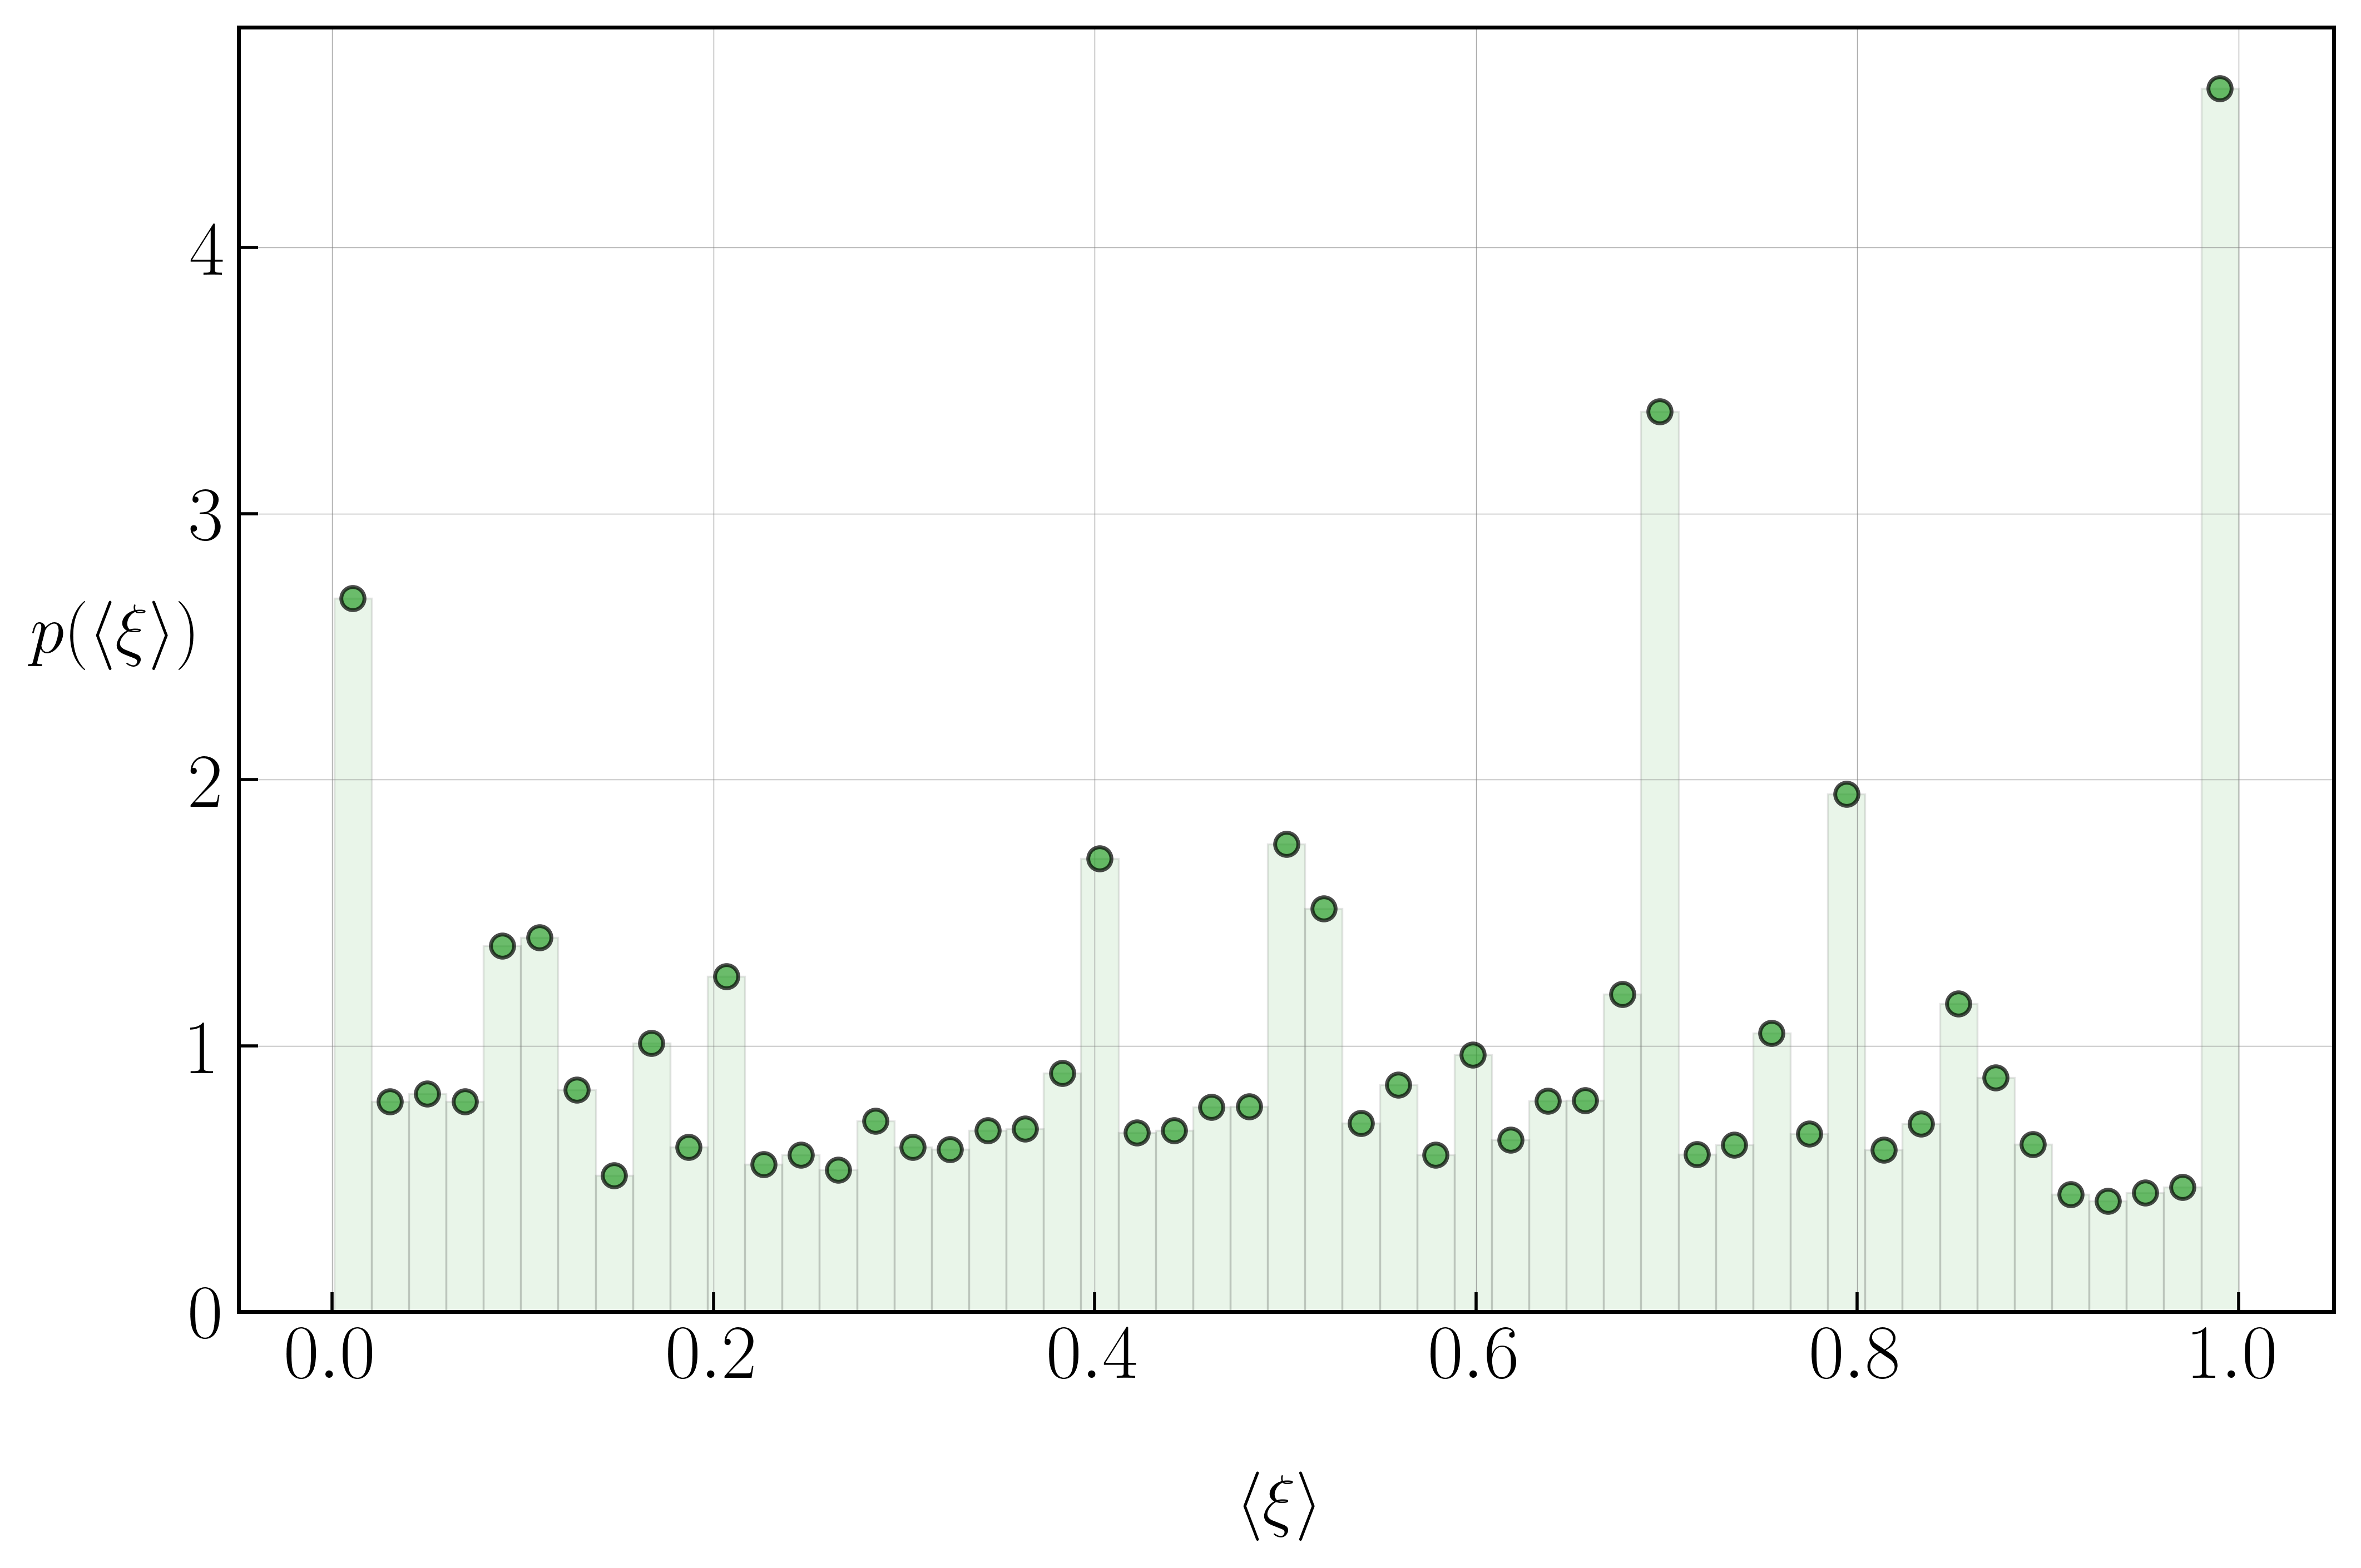

In [60]:
# plot_distribution(tx.groupby('source').frac_out.mean())
# data = tx.groupby('source').frac_out.mean()
data = agents.mean_frac_out

xlabel = r'$\langle \xi \rangle$'
ylabel = r'$p(\langle \xi \rangle)$'

fig,ax=plt.subplots()
plt.hist(data,edgecolor='k',alpha = 0.1,color='tab:green', bins=51,density = True, linewidth=0.5,align='mid')
# plt.hist(data2,edgecolor='k',alpha = 0.5,color='tab:red', bins=51,density = True, linewidth=0.5)

plot_distribution(data,ax=ax,color='tab:green',markeredgecolor='k',alpha = 0.7, linestyle='', marker='o',log_bin=False,log_scale=False,n_bins=51)
plt.xlabel(xlabel,rotation=0,labelpad=20)
plt.ylabel(ylabel,rotation=0,labelpad=20)

In [ ]:
fig.savefig(f'{fig_path}/spending_shares.png',bbox_inches='tight', pad_inches=0.1)

Text(0, 0.5, '$\\bf{p(\\xi)}$')

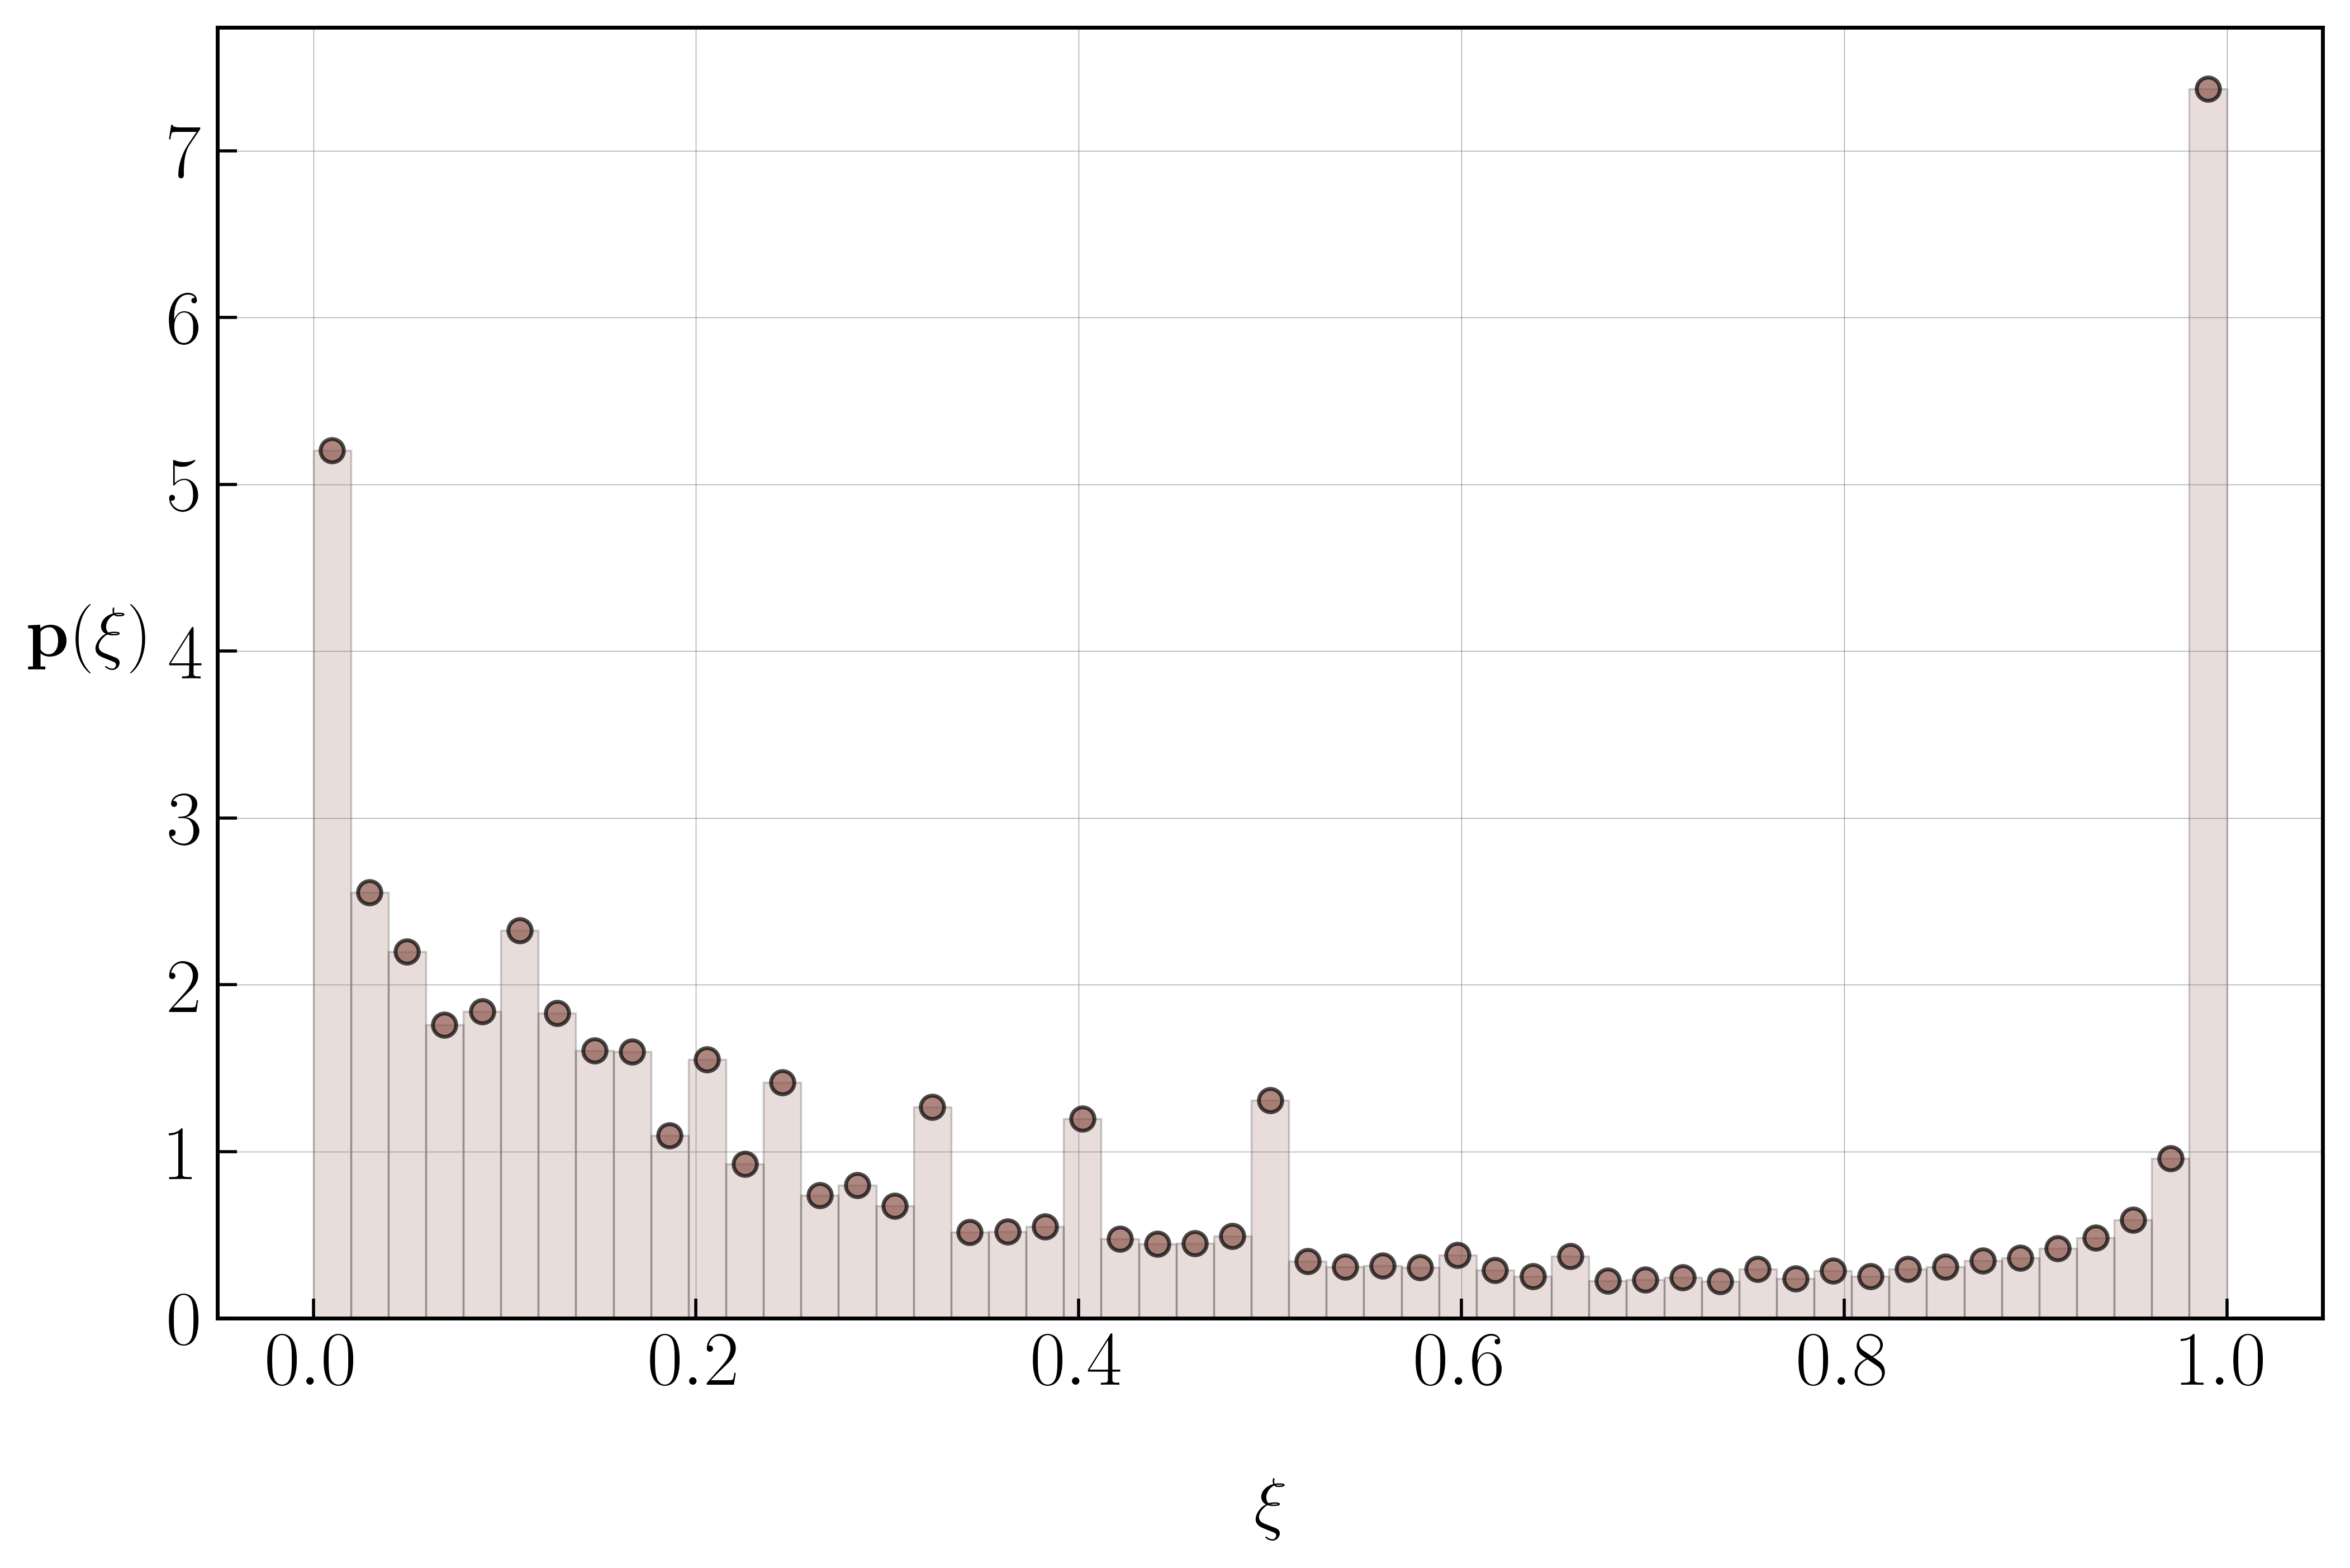

In [61]:
# plot_distribution(tx.frac_out)
bins = 51
data = tx.frac_out

fig = plt.figure()
plt.hist(data, bins=bins,edgecolor='k',color='tab:brown',density=True,alpha=0.2,linewidth=0.5,align='mid')
plot_distribution(data,ax=plt.gca(),color='tab:brown',markeredgecolor='k',alpha = 0.7, linestyle='', marker='o',log_bin=False,log_scale=False,n_bins=51)

xlabel = r'$\bf{\xi}$'
ylabel = r'$\bf{p(\xi)}$' 

plt.xlabel(xlabel,rotation=0,labelpad=20)
plt.ylabel(ylabel,rotation=0,labelpad=20)





In [ ]:
fig.savefig(f'{fig_path}/spending_spectrum.png',bbox_inches='tight', pad_inches=0.1)

Text(0, 0.5, '$\\mathbf{p(w)}$')

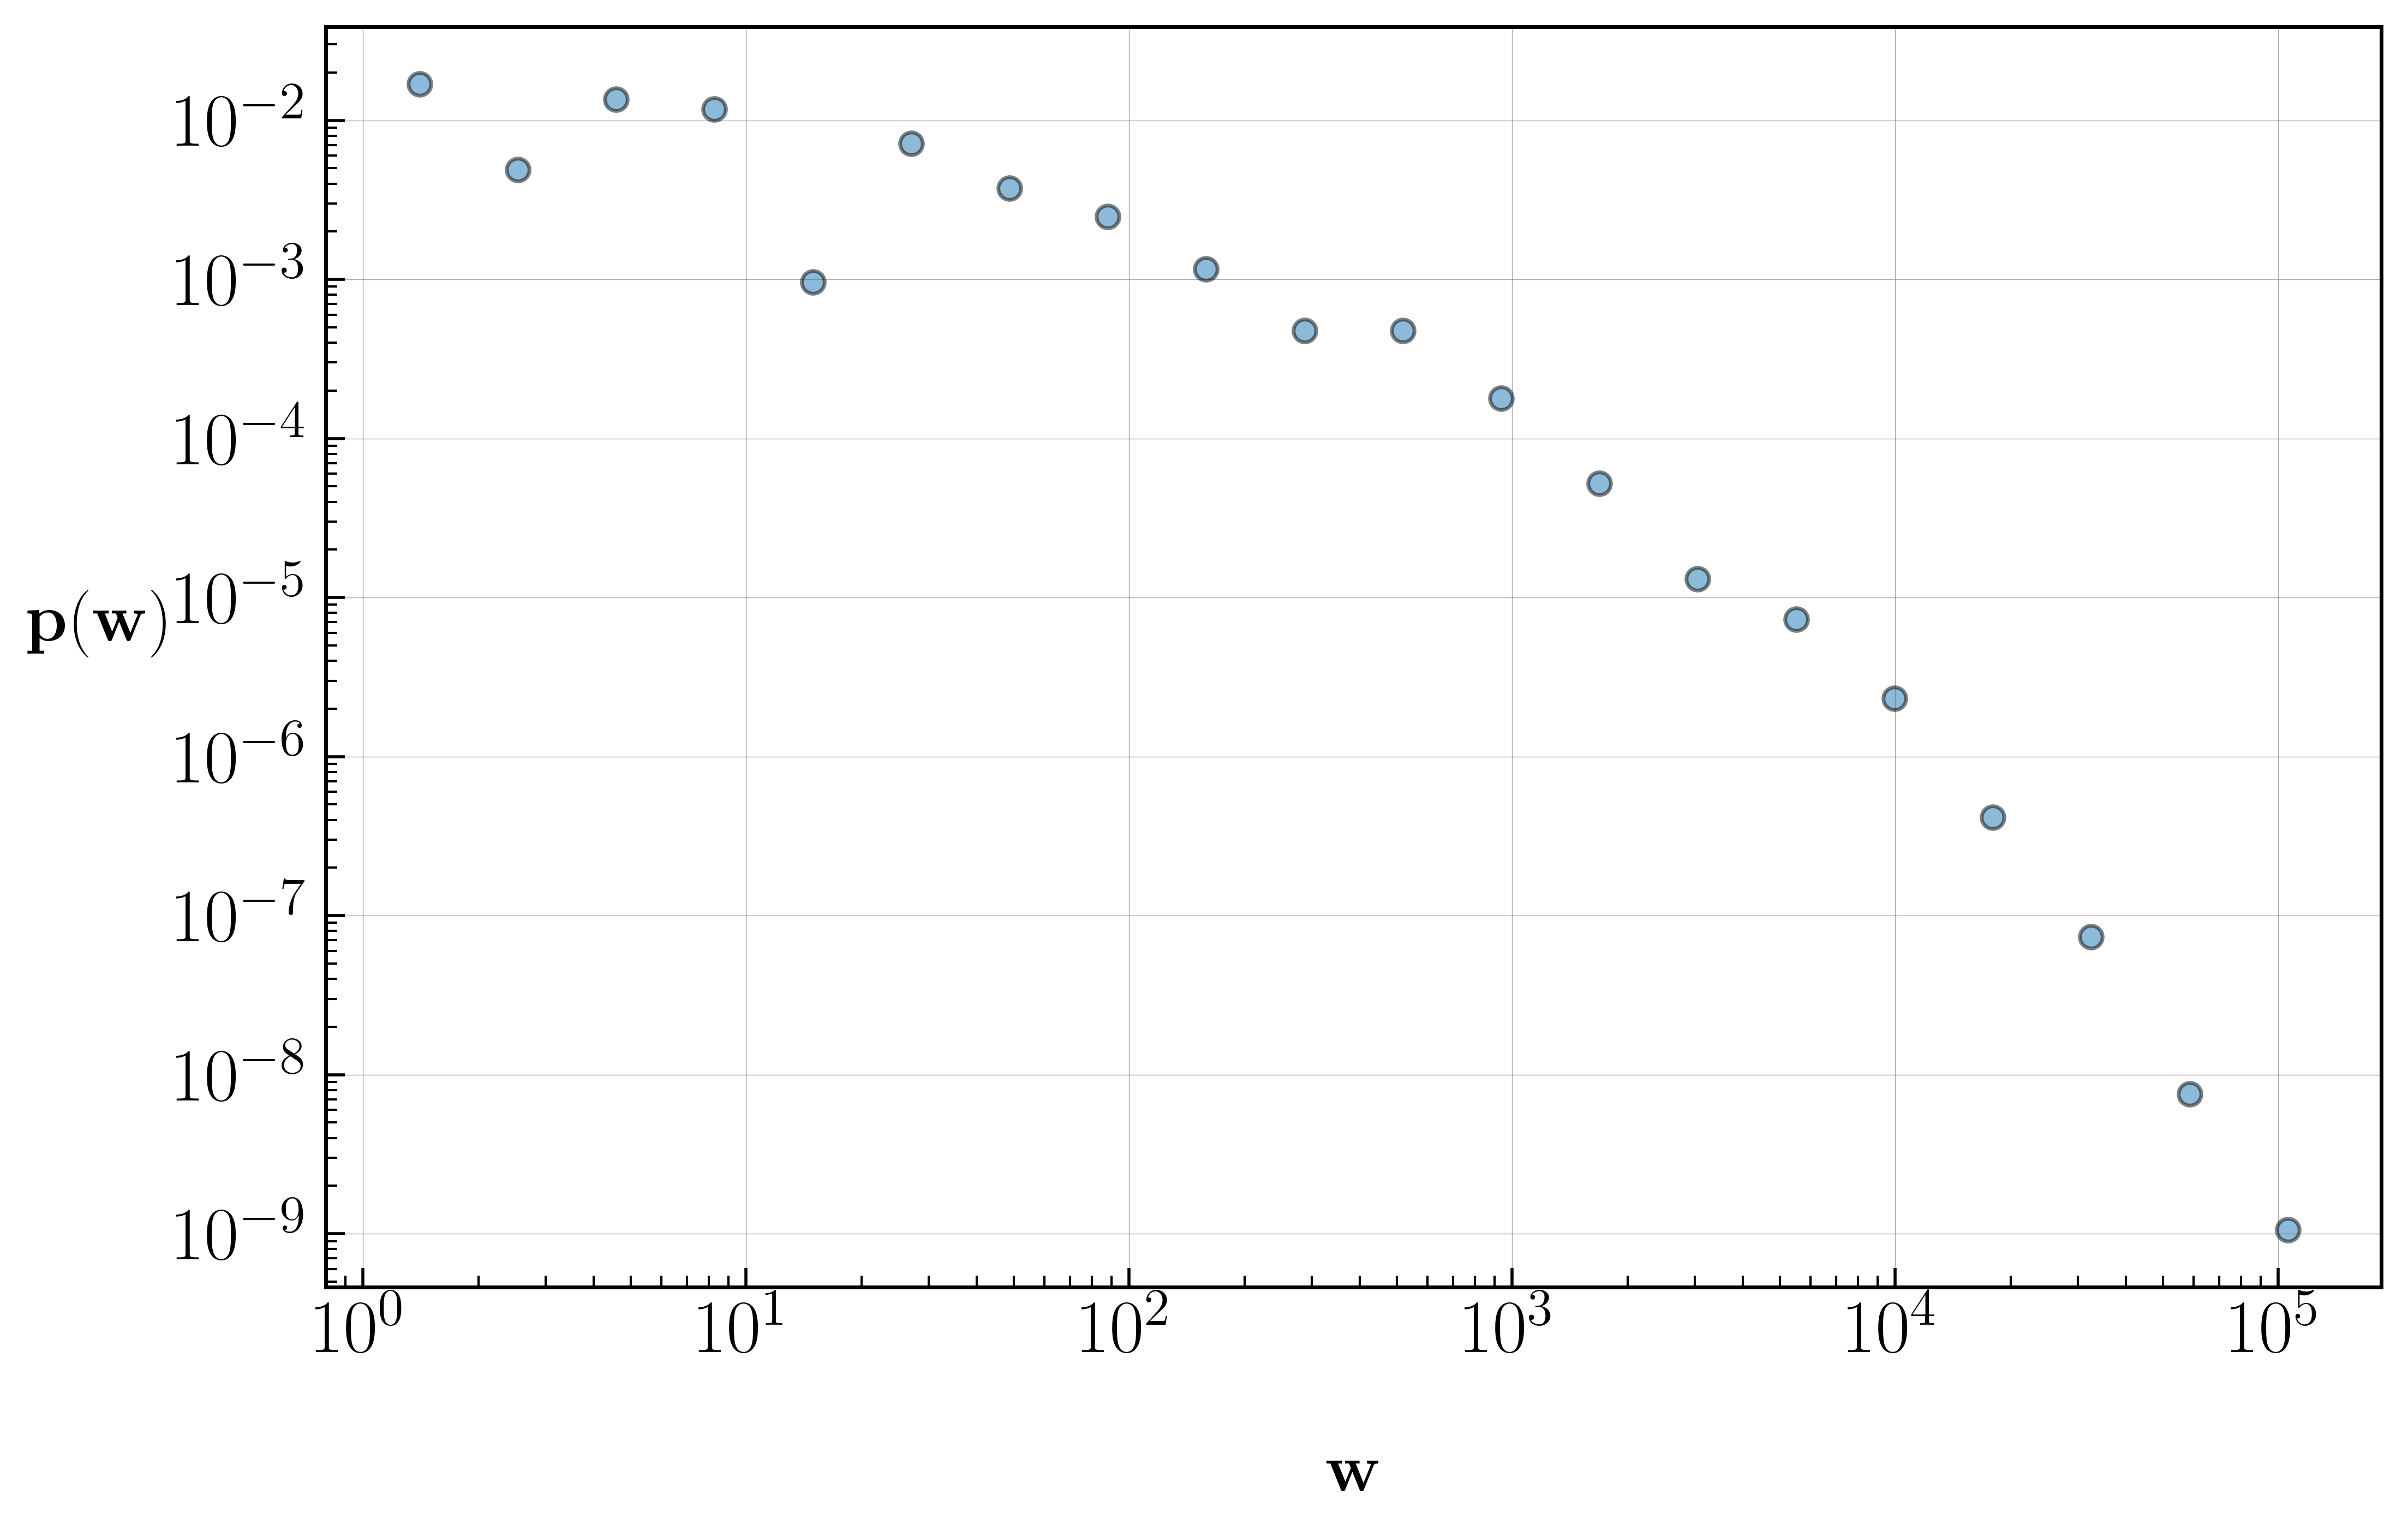

In [62]:
fig = plt.figure()
plot_distribution(tx.weight,marker = 'o',linestyle='',markeredgecolor='k',alpha=0.5,ax=plt.gca())
plt.xlabel(r'$\mathbf{w}$',rotation=0,labelpad=20)
plt.ylabel(r'$\mathbf{p(w)}$',rotation=0,labelpad=20)


In [ ]:

fig.savefig(f'{fig_path}/weight.png',bbox_inches='tight', pad_inches=0.1)

In [63]:
all_balances = balance_constructor(TXDF[['date','source','target','source_bal_post','target_bal_post','type','id']])

all_balances['period'] = pd.cut(all_balances.date, bins=20,labels=False) #period by date

# all_balances['period'] = pd.cut(all_balances.index, bins=20,labels=False) #period by nr of txns


filtered_balances = all_balances.loc[(all_balances.crid.isin(filtered_crid)) & (all_balances.type == 'STANDARD')]

bal_pivot = pd.pivot_table(filtered_balances, index='crid',columns='period', values='balance', aggfunc='last')
bal_pivot = bal_pivot.ffill(axis=1)

js_test_balances = compute_sequential_js(bal_pivot)
# plt.plot()

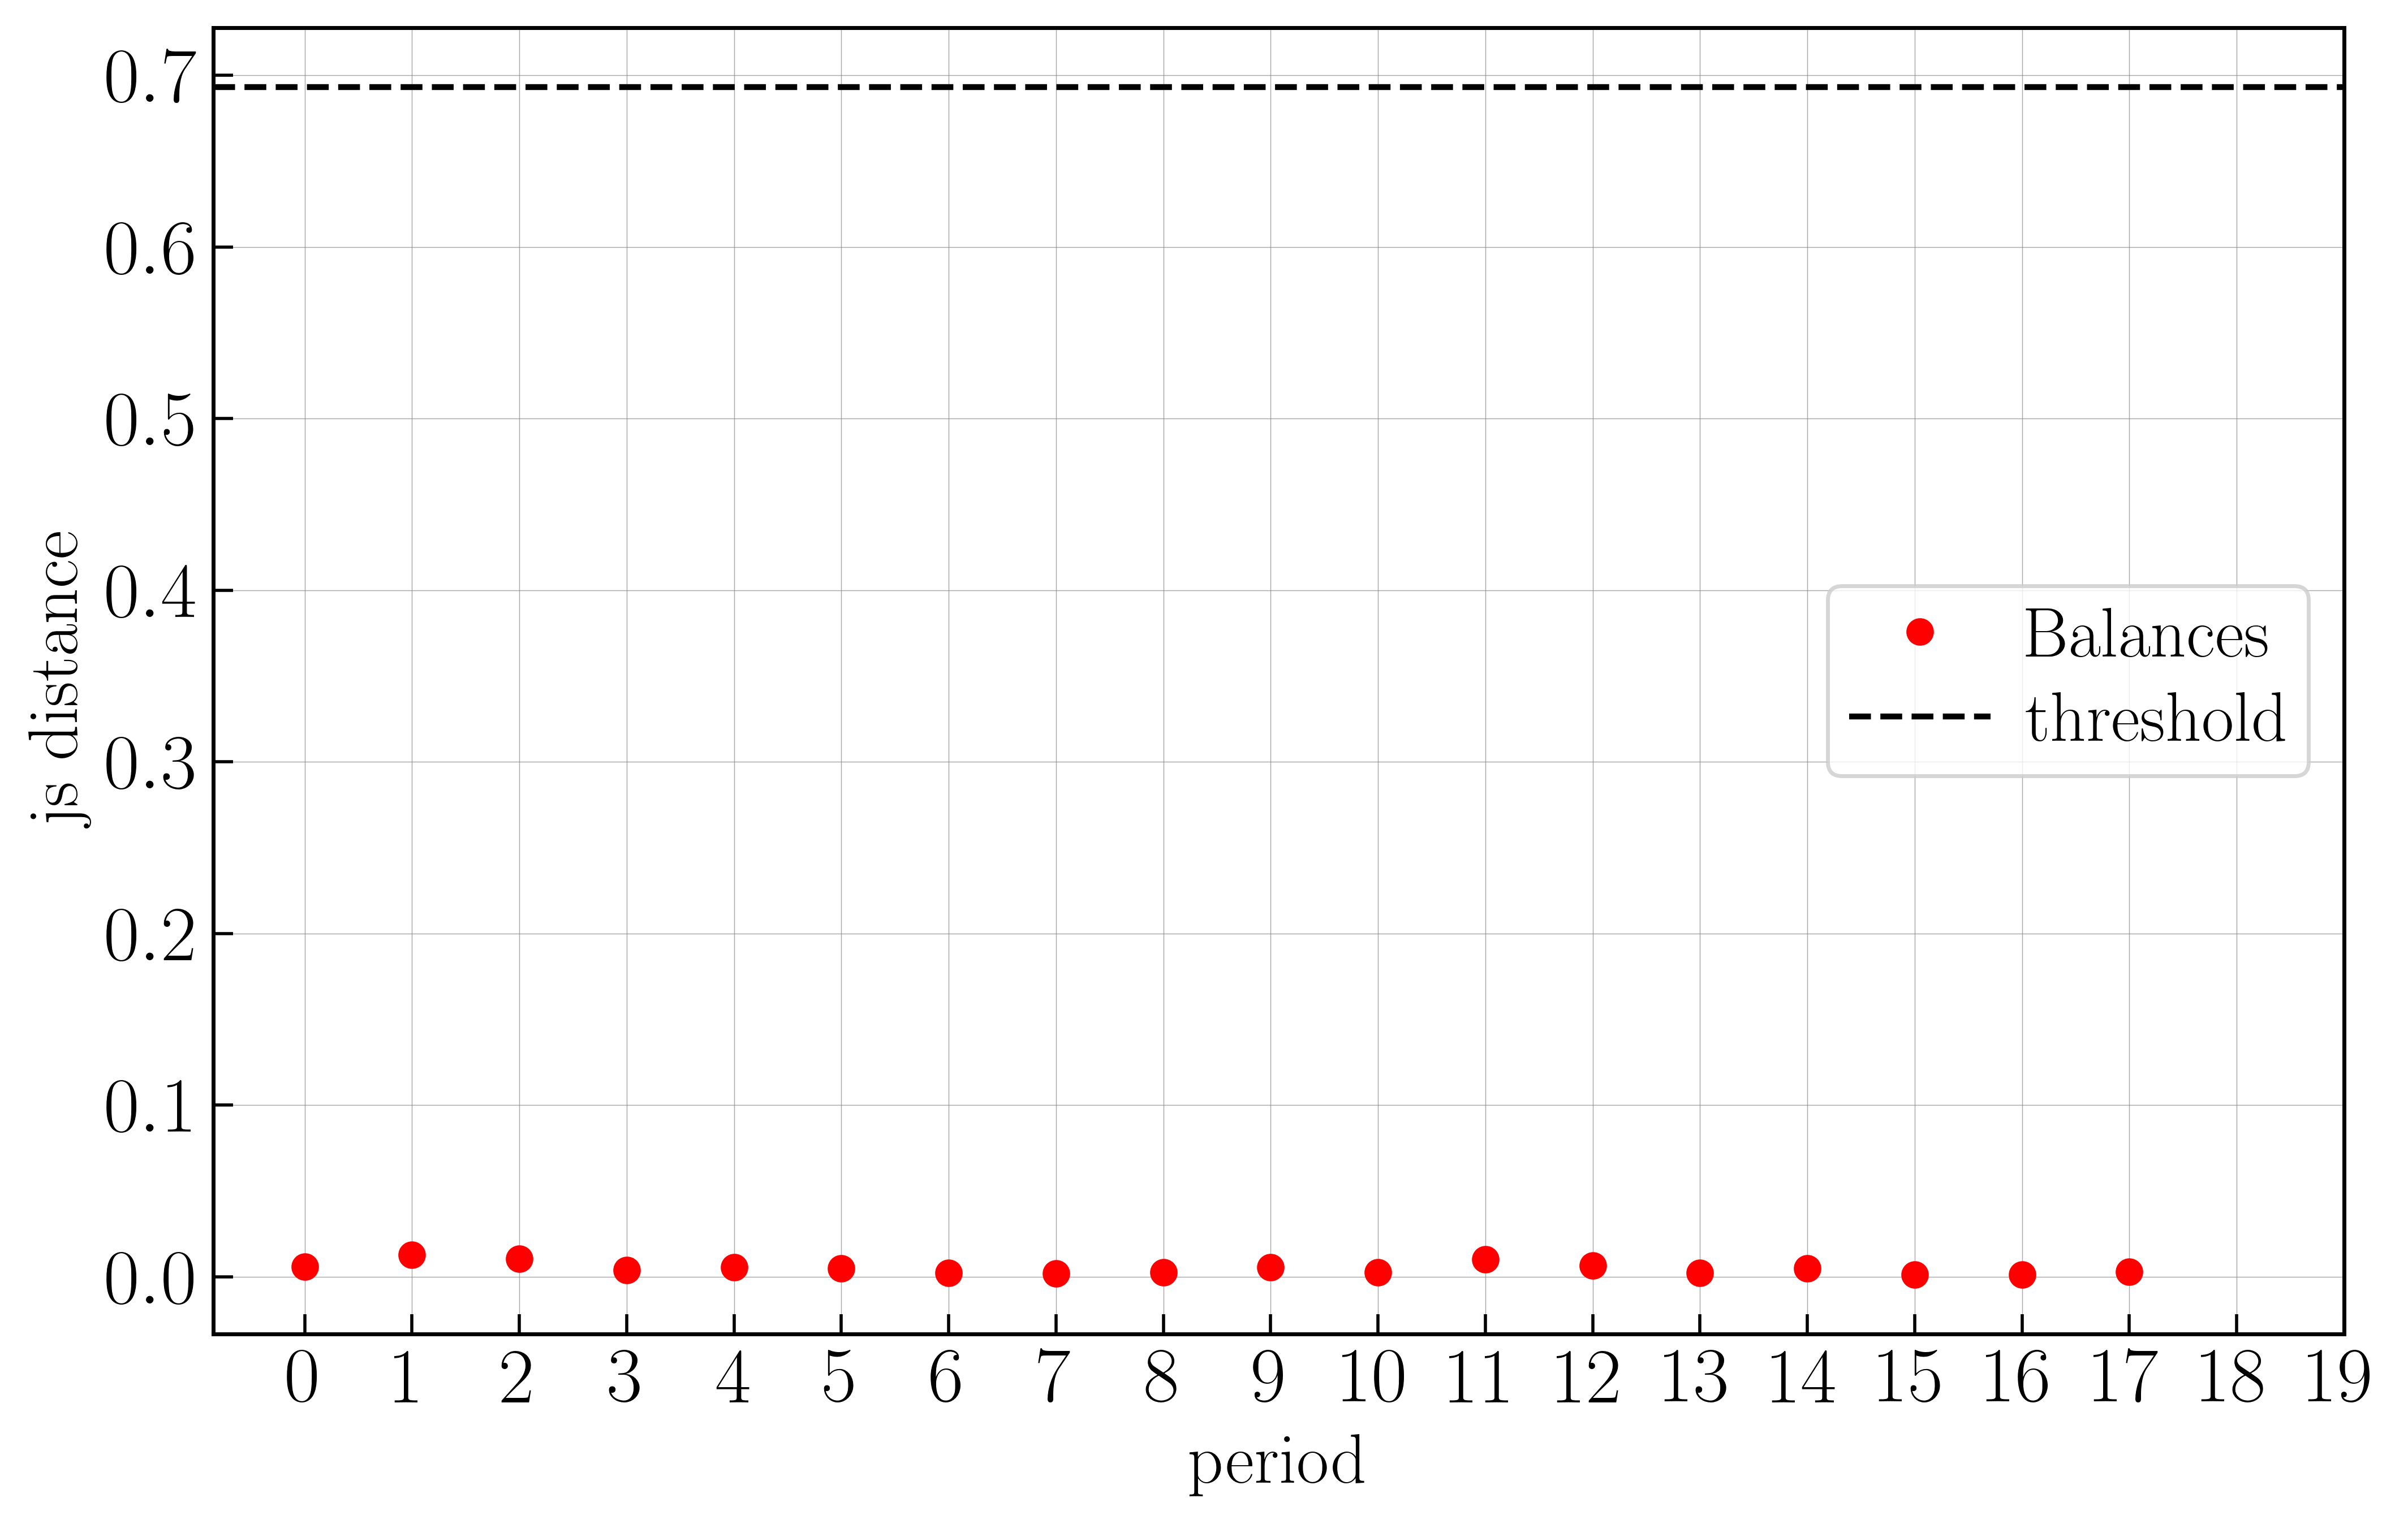

In [64]:
fig = plt.figure()
plt.plot(js_test_balances.values(),'ro',label = 'Balances')
plt.axhline(y=np.log(2), label='threshold', color='k', linestyle='--')
plt.xlabel('period')
plt.ylabel('js distance')
plt.xticks(np.arange(0, 20, 1))
plt.legend()


In [ ]:
fig.savefig(f'{fig_path}/bal_stationary.png',bbox_inches='tight', pad_inches=0.1)

Text(0, 0.5, '$\\mathbf{p(b)}$')

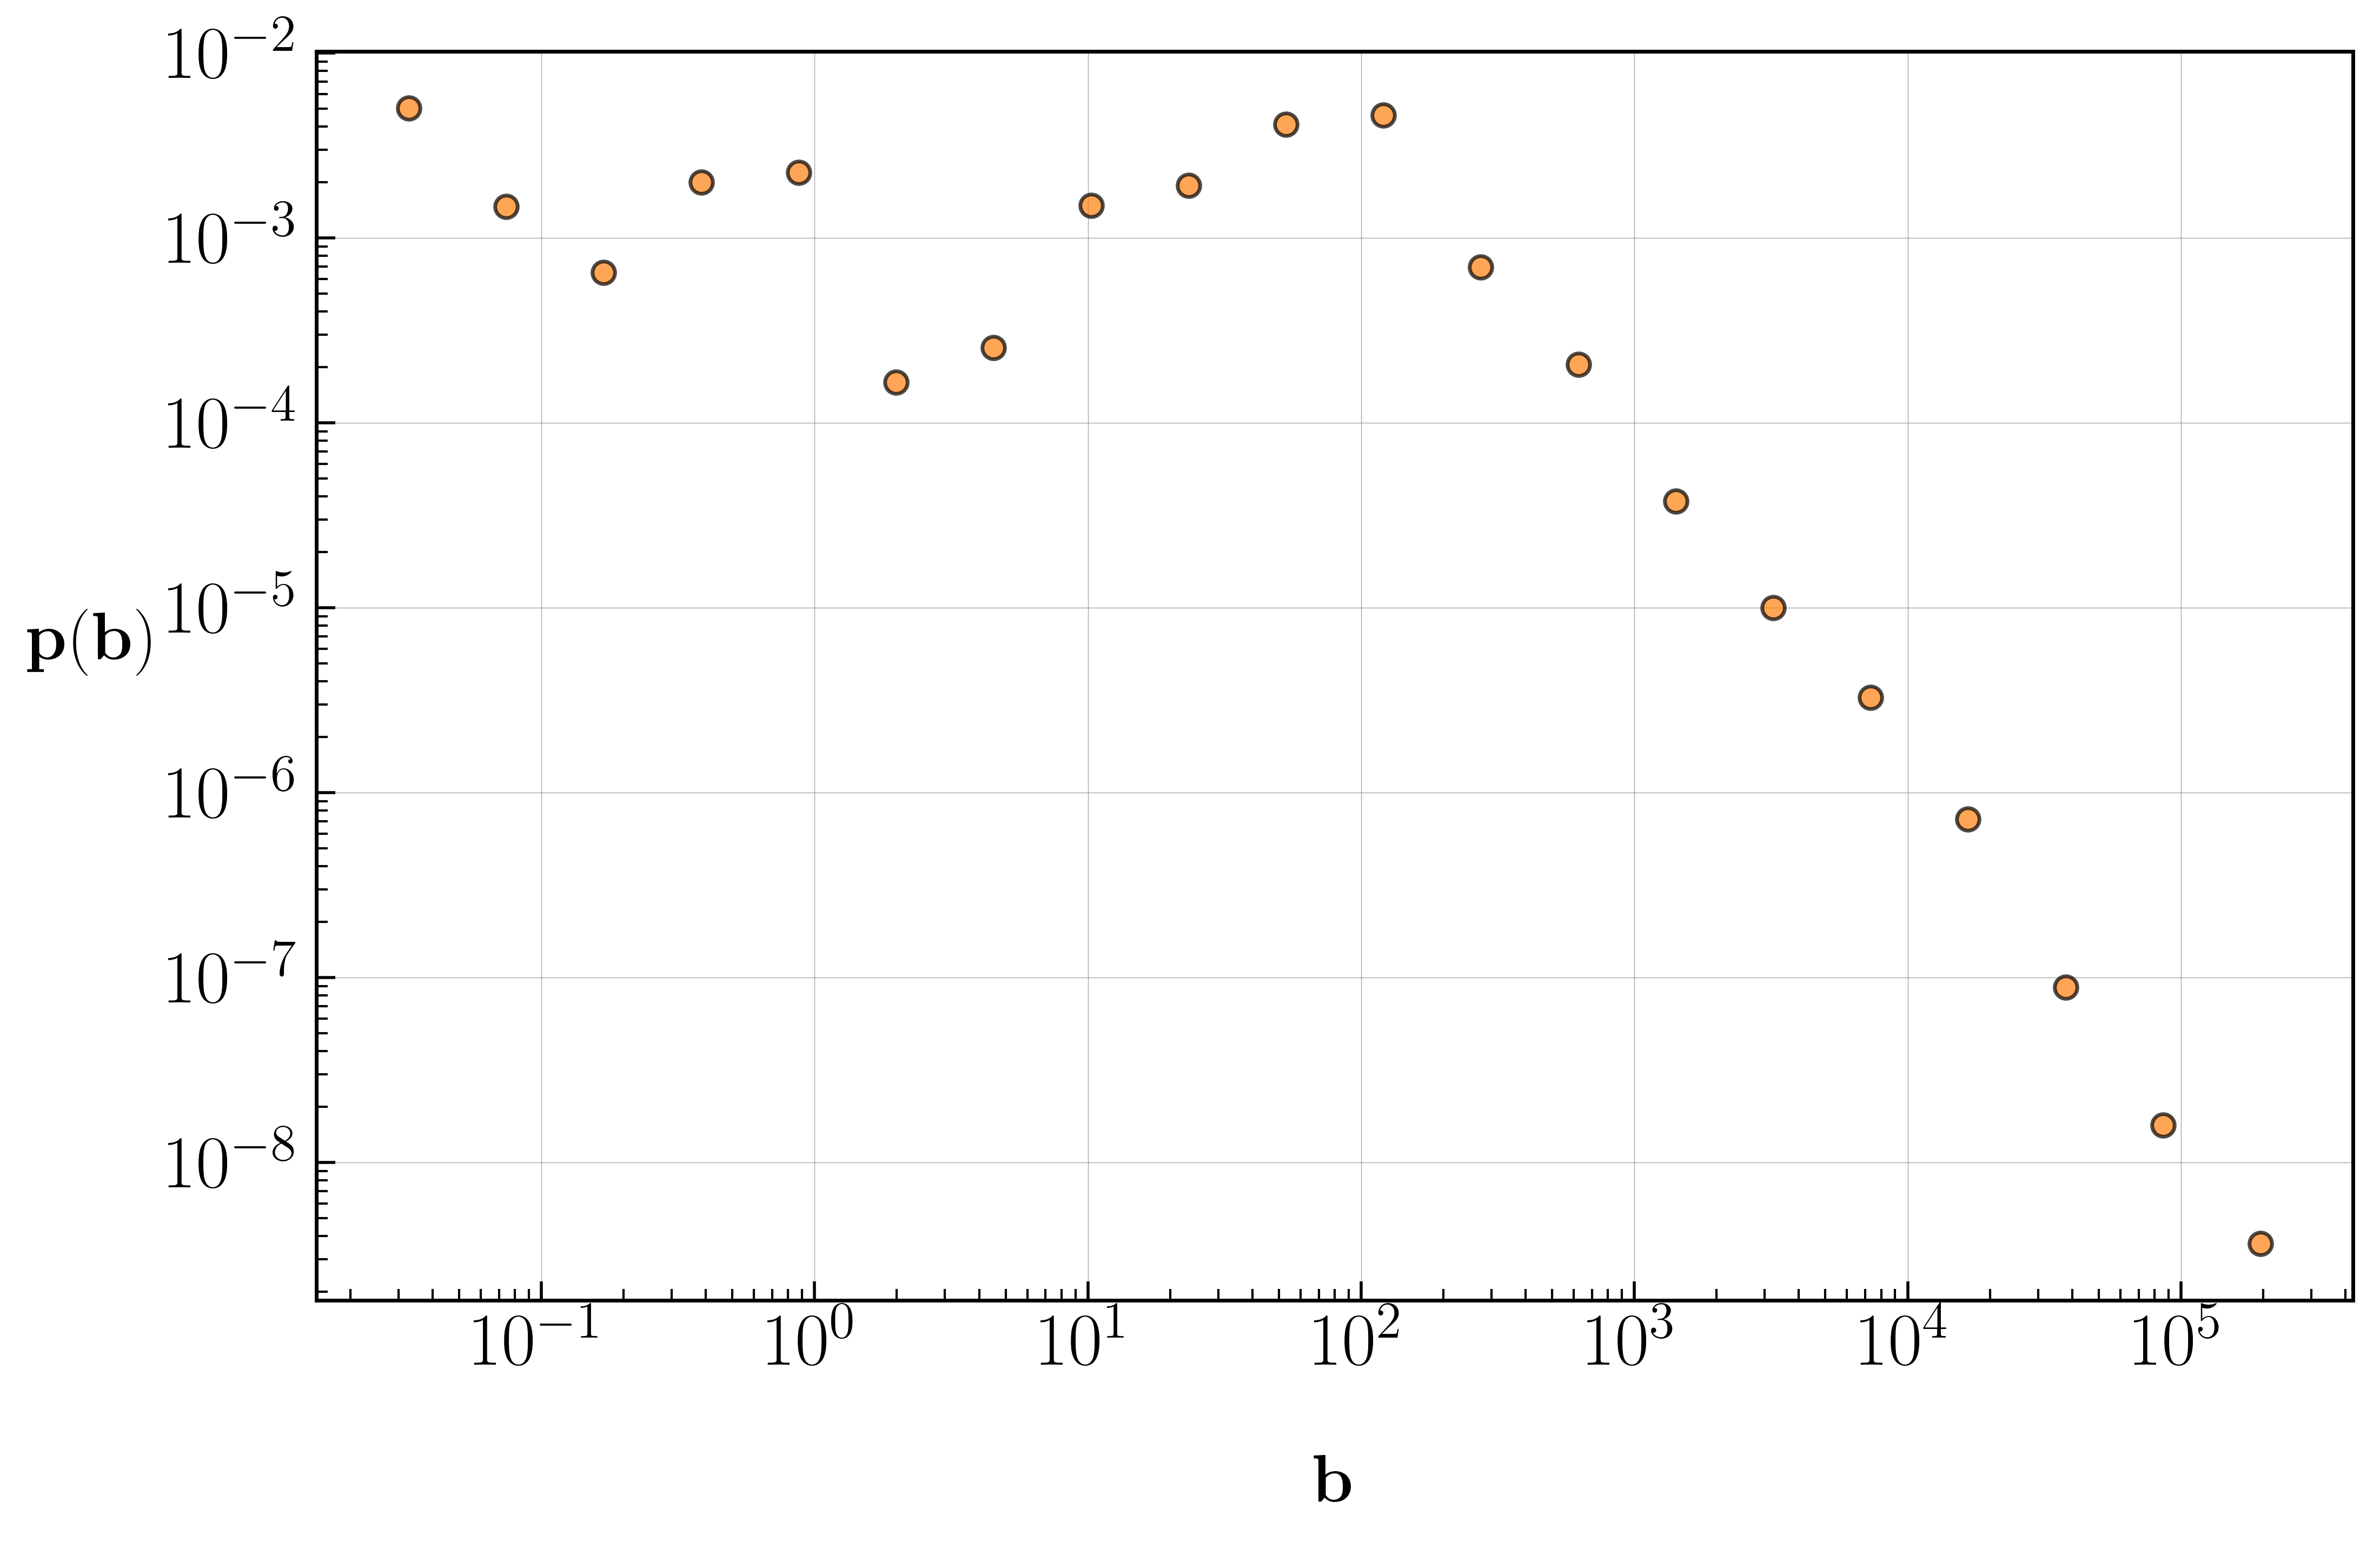

In [65]:
fig = plt.figure()

line1 = plot_distribution(bal_pivot.iloc[:,-1],ax=plt.gca(),marker='o',markeredgecolor='k',linestyle='',alpha = 0.7,color='tab:orange')
plt.xlabel(r'$\mathbf{b}$',rotation=0,labelpad=20)
plt.ylabel(r'$\mathbf{p(b)}$',rotation=0,labelpad=20)


In [ ]:

fig.savefig(f'{fig_path}/final_bal.png',bbox_inches='tight', pad_inches=0.1)


FileNotFoundError: [Errno 2] No such file or directory: '/home/claudio/tesi/sarafu/wait/weightandbalance.png'

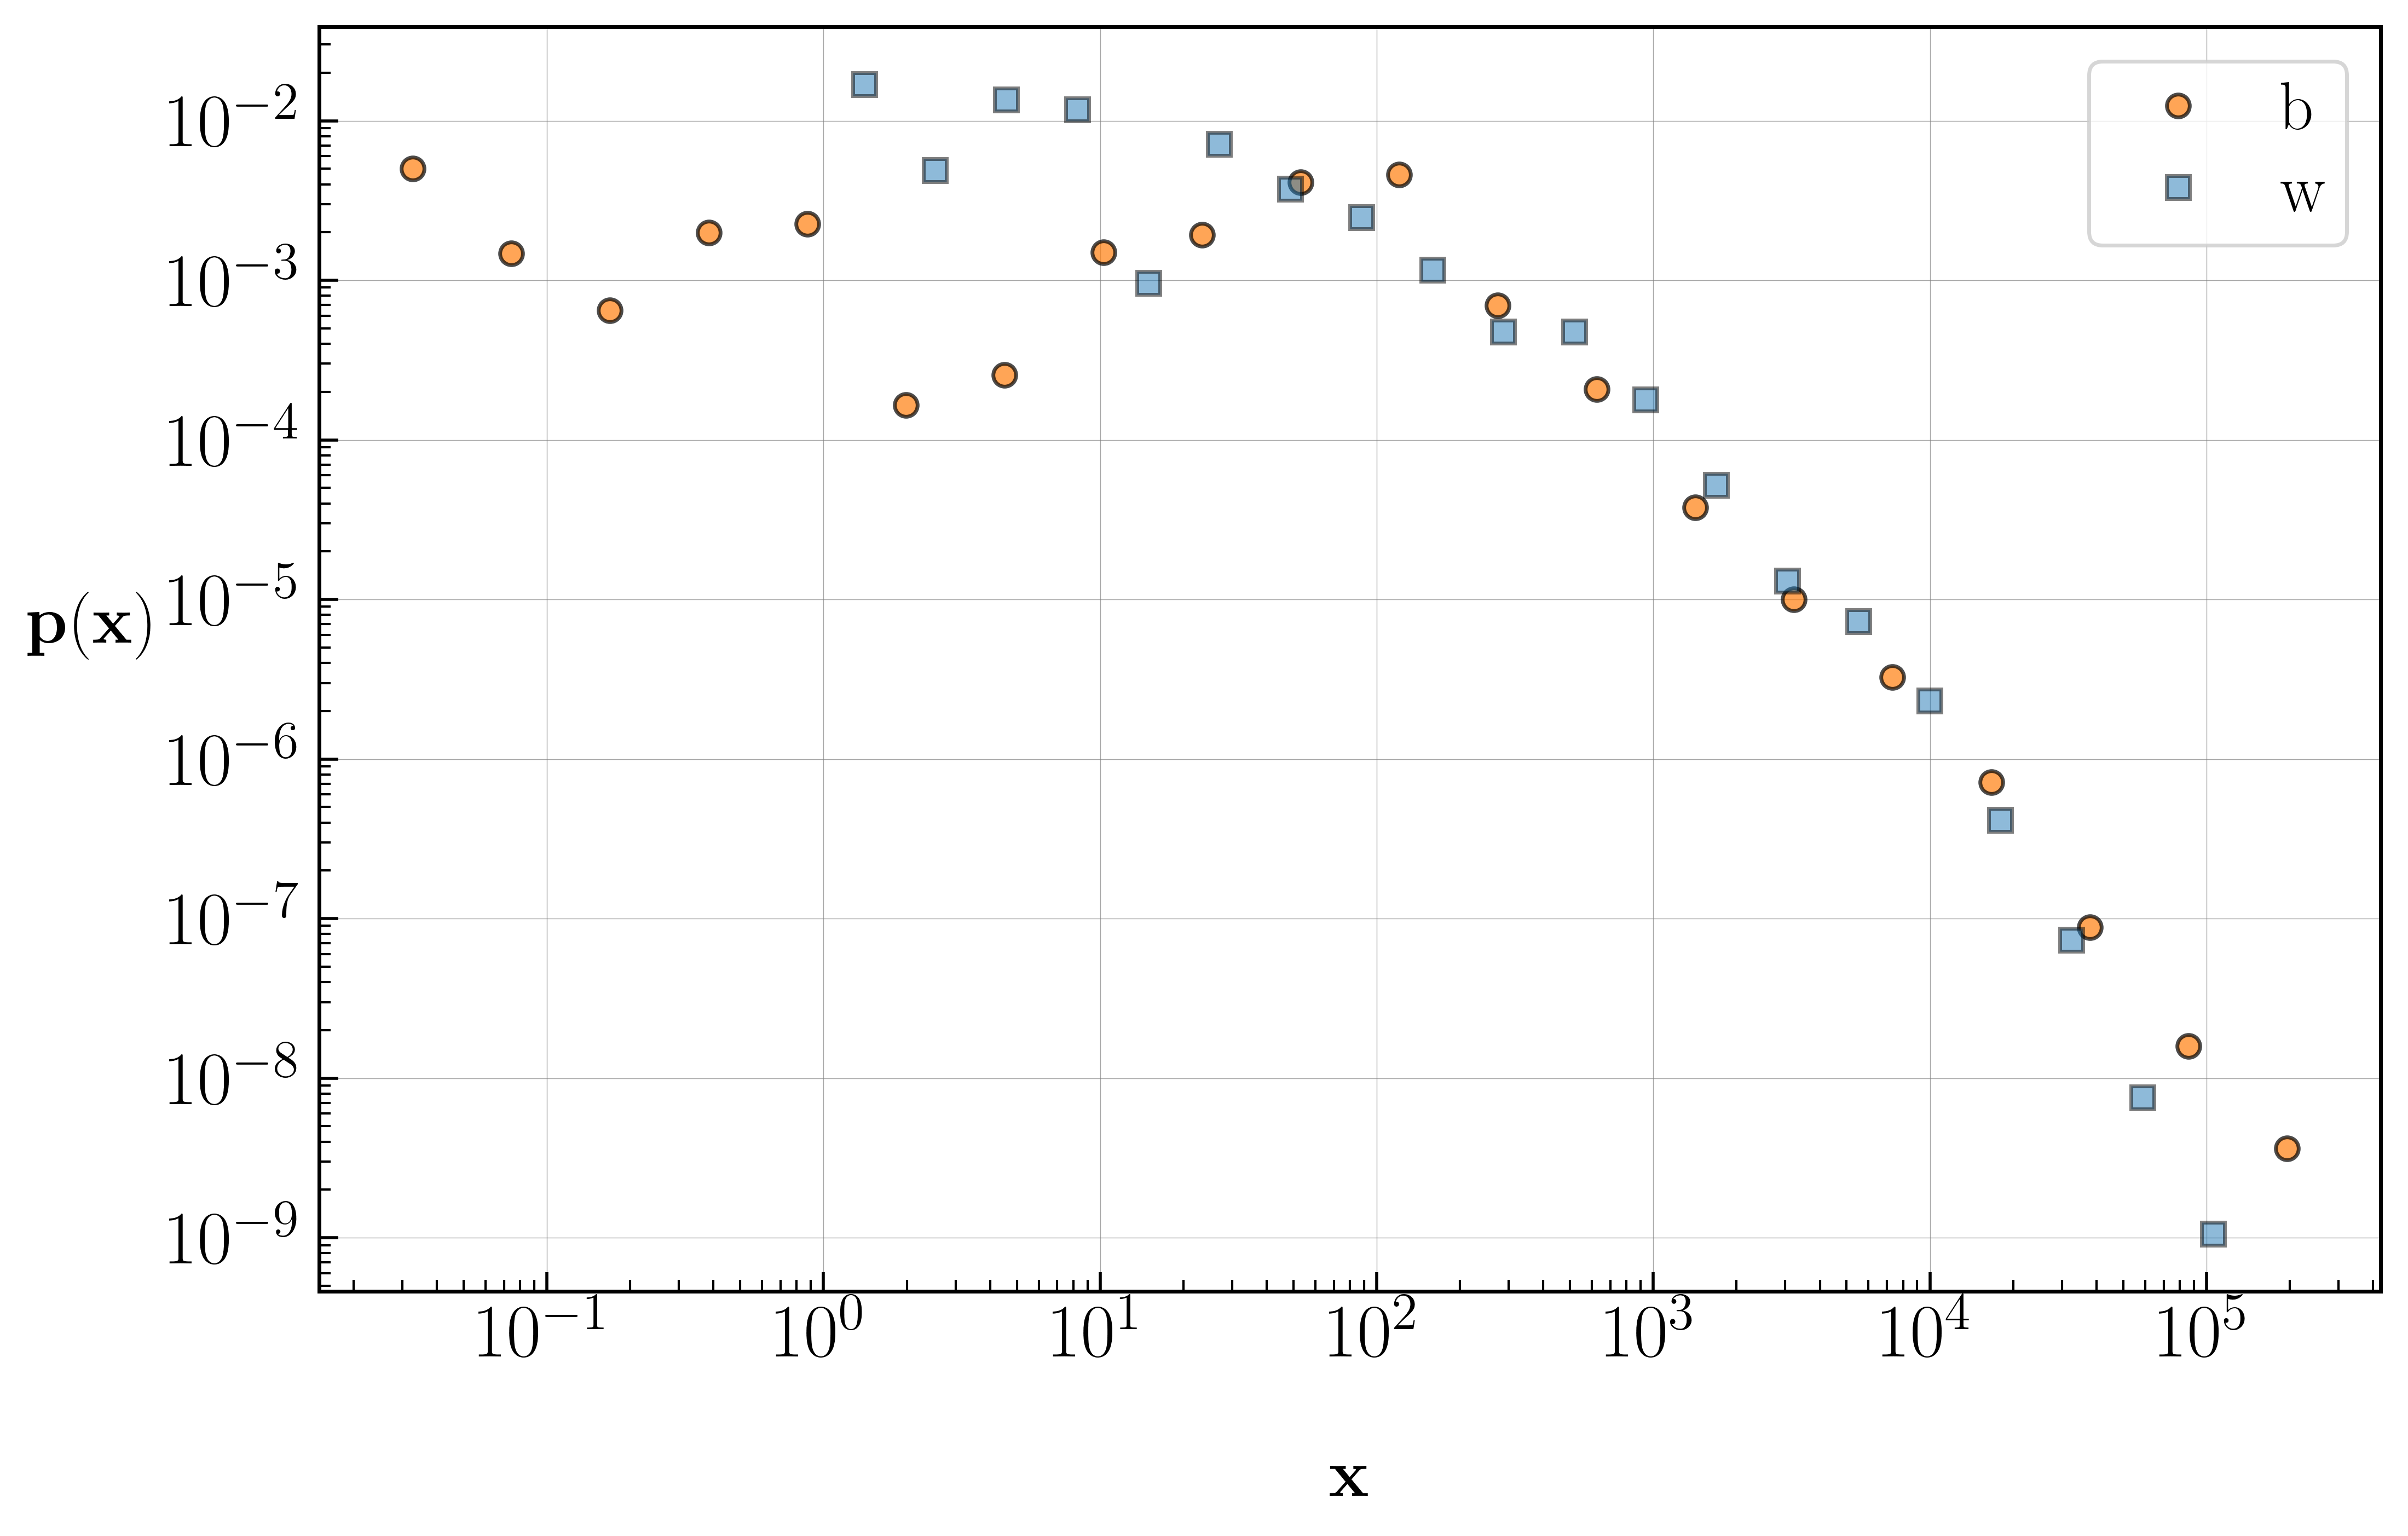

In [ ]:
fig = plt.figure()
plot_distribution(bal_pivot.iloc[:,-1],ax=plt.gca(),marker='o',markeredgecolor='k',linestyle='',alpha = 0.7,color='tab:orange',label='b')
plot_distribution(tx.weight,marker = 's',linestyle='',markeredgecolor='k',alpha=0.5,ax=plt.gca(),label='w')
plt.xlabel(r'$\mathbf{x}$',rotation=0,labelpad=20)
plt.ylabel(r'$\mathbf{p(x)}$',rotation=0,labelpad=20)


In [ ]:

fig.savefig(f'{fig_path}/weightandbalance.png',bbox_inches='tight', pad_inches=0.1)

In [67]:
agents.loc[:,['tx_in', 'tx_out']].min()

tx_in     1.0
tx_out    1.0
dtype: float64

# Fits

Chosen xmin for tx_out: 2.0
KS Statistic: 0.04353955946263399
Quantile of data used for the fit: 0.8061 (80.61%)
Chosen xmin for tx_in: 1.0
KS Statistic: 0.0811173462219753
Quantile of data used for the fit: 1.0000 (100.00%)


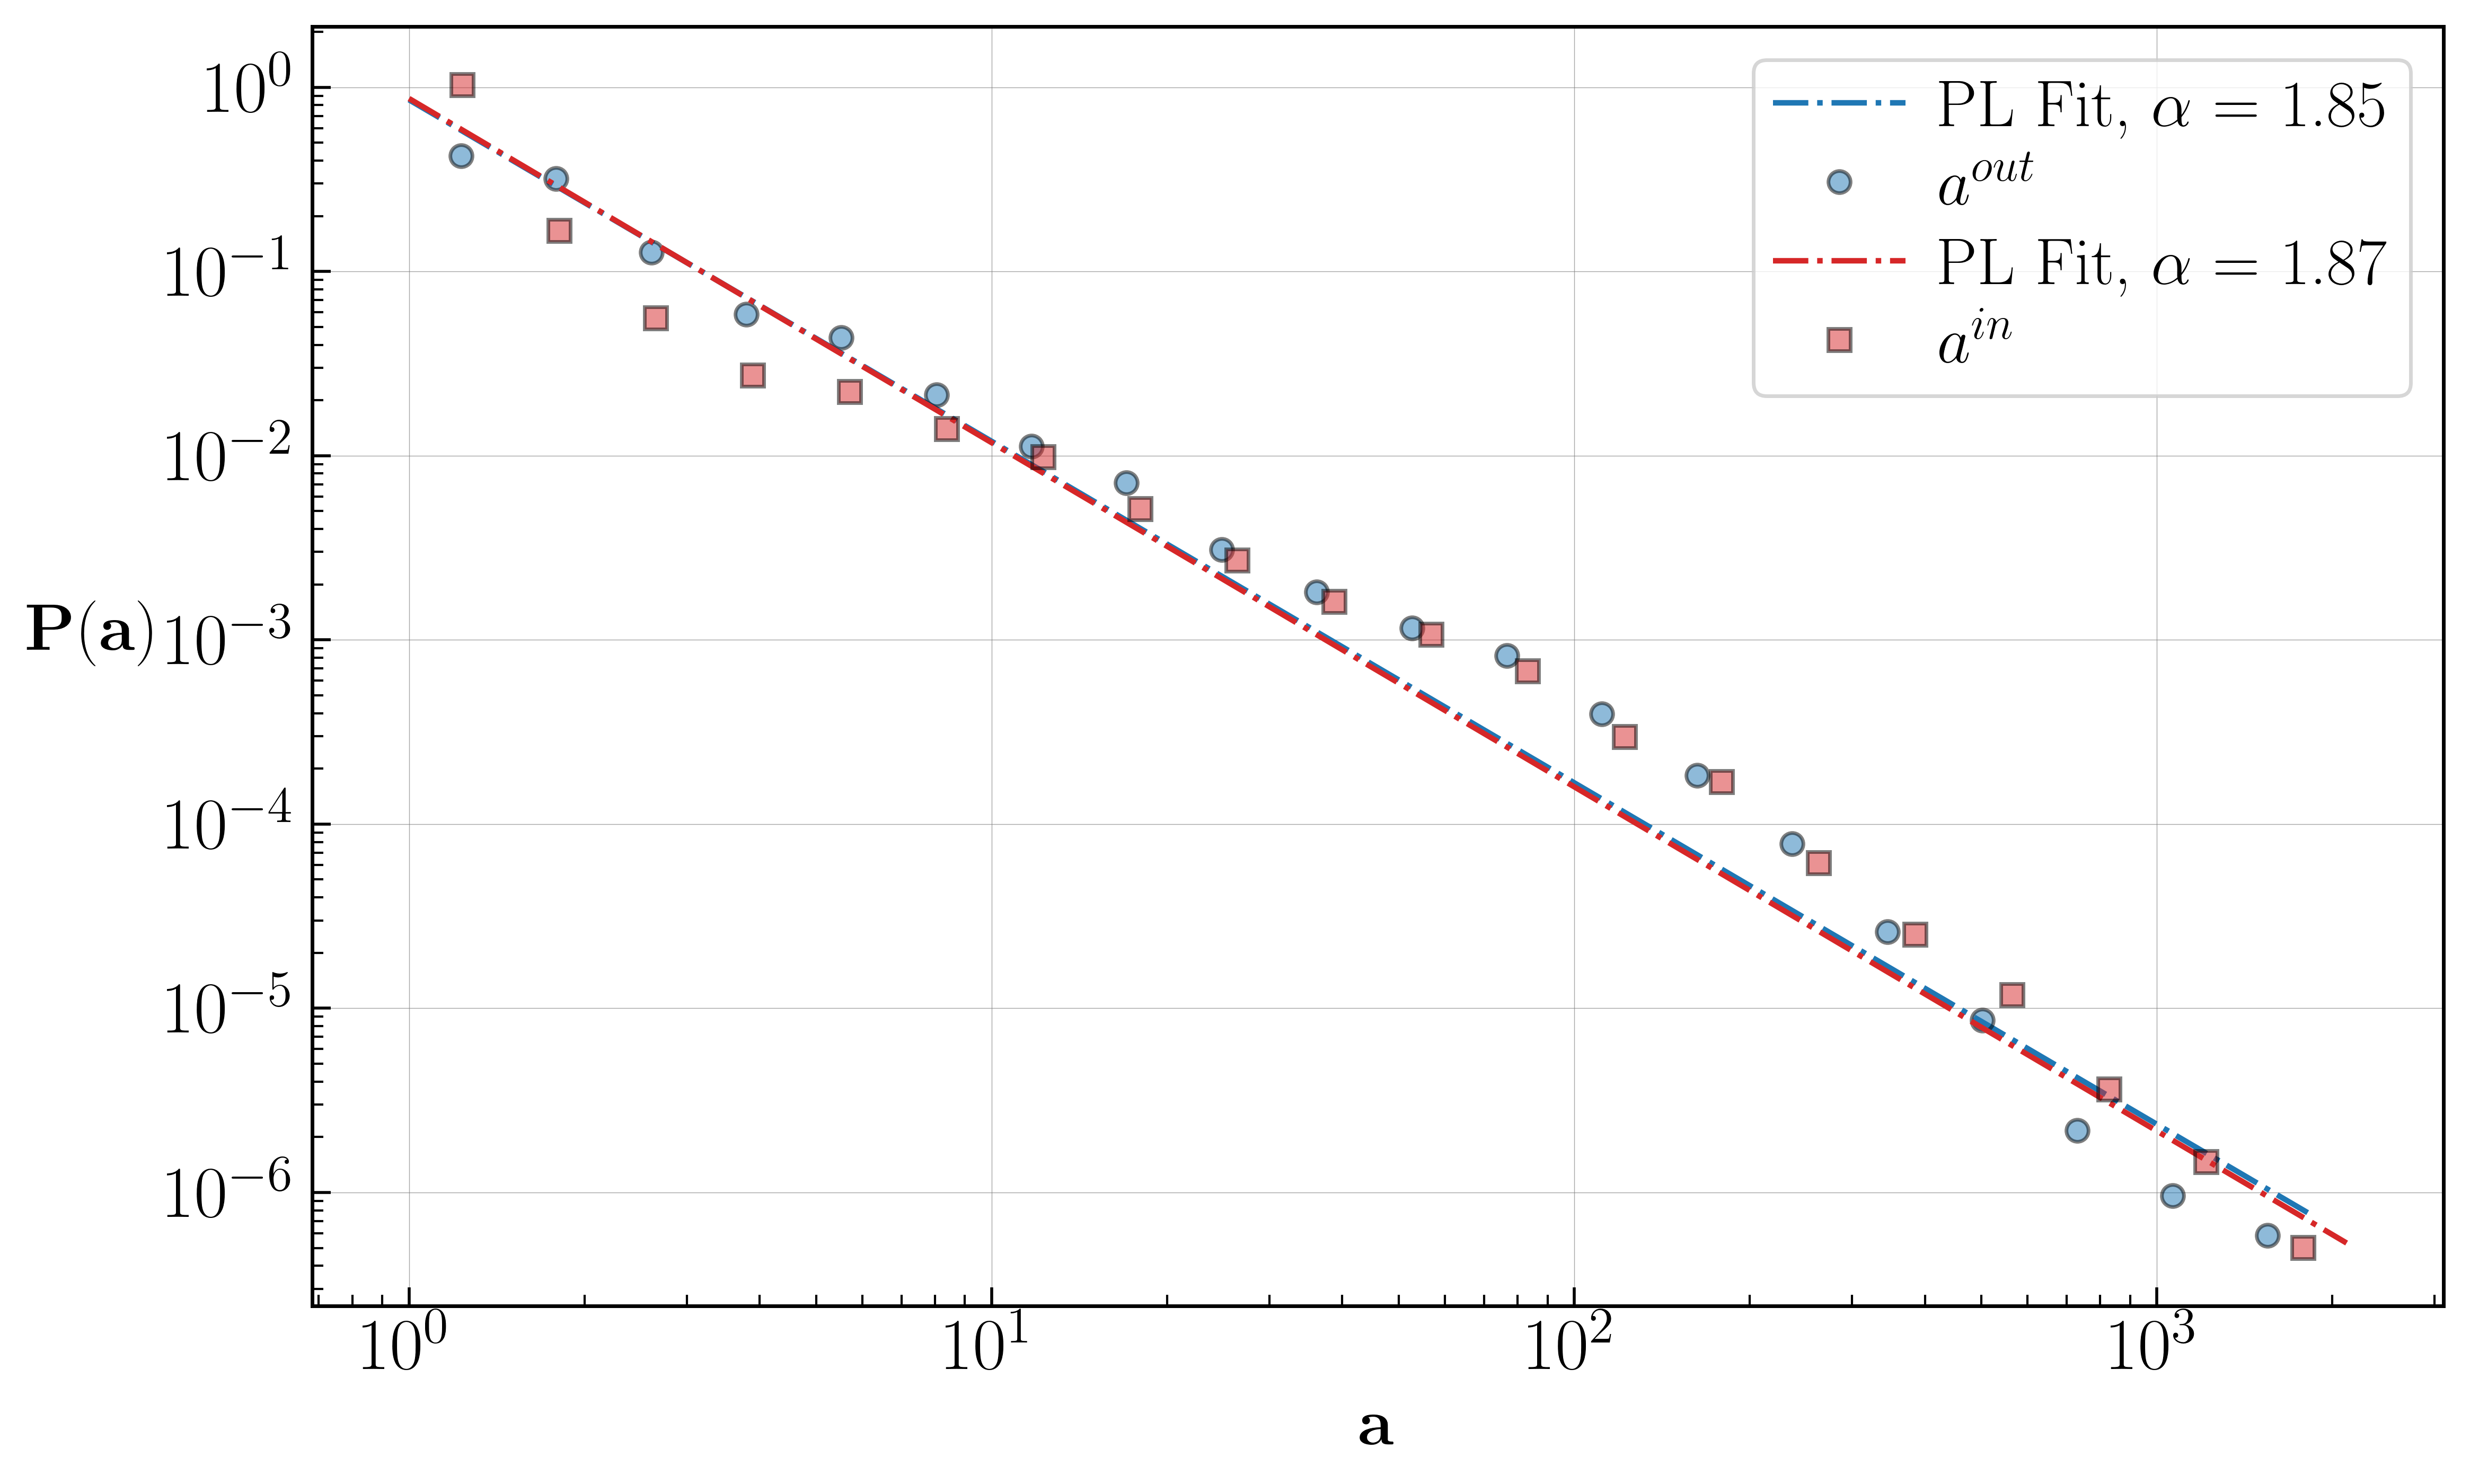

FileNotFoundError: [Errno 2] No such file or directory: '/home/claudio/tesi/sarafu/wait/actattr_fit.png'

In [68]:

# Boolean flag to control fitting
perform_fit = 1

alpha = {}
c = {}
colors = ['tab:blue', 'tab:red']
markers = ['o', 's']
disc = False

if perform_fit:
    columns = ['tx_out', 'tx_in']
    labels = [r'$a^{out}$', r'$a^{in}$']
#     if disc:
#         columns = ['tx_out', 'tx_in']
#         labels = [r'$n^{out}$', r'$n^{in}$']
#     else:
#         # columns = ['activity', 'attractiveness']
        
# else:
#     labels = [r'$n^{out}$', r'$n^{in}$']
#     columns = ['tx_out', 'tx_in']



fig, ax = plt.subplots()
fits = {}

for idx, col in enumerate(columns):
    data = agents[col]
    # data = agents[col]/agents[col].sum()
    xmin_plot = data[data != 0].min()  # Start plot from same min
    xmax = data.max()

    # Automatically determine xmin for 20% quantile
    # xmin_fit = find_xmin_by_quantile(data, quantile=0.30)
    xmin_fit = data.quantile(0.30)

    if perform_fit:
        # Fit power-law model
        fit = pwl.Fit(data, xmin=xmin_fit, xmax=xmax, discrete=disc, estimator='Hill', estimate_discrete=disc)
        alpha[col] = fit.power_law.alpha
        xmin_fit = fit.xmin
        xmax = data.max()
        
        print(f"Chosen xmin for {col}: {xmin_fit}")
        print(f"KS Statistic: {fit.D}")
        q = np.sum(data >= xmin_fit) / len(data)
        print(f"Quantile of data used for the fit: {q:.4f} ({q * 100:.2f}%)")

        # Recalculate C for full range
        C_adjusted = recalculate_constant(alpha[col], xmin_plot, xmax)
        
        if disc:
            CC = fit.power_law._pdf_discrete_normalizer
        else:
            CC = fit.power_law._pdf_continuous_normalizer

        # Generate x-values for fitted curve starting from xmin_plot
        x = np.logspace(np.log10(xmin_plot), np.log10(xmax), 1000)
        y = powerlaw_function(x, alpha=alpha[col], xmin=xmin_plot, C=C_adjusted)

        # Plot adjusted power-law fit
        ax.plot(x, y, label=r'PL Fit, $\alpha$ = %.2f' % alpha[col], color=colors[idx], linestyle='-.')

        fits[col] = {'alpha':fit.power_law.alpha, 'xmin':fit.xmin, 'xmax':fit.xmax}
        with open('sarafu_info.txt','a') as f:
            print(f'Power-law fit for {col}: alpha = {fit.power_law.alpha}, xmin = {fit.xmin}, xmax = {fit.xmax}',file=f)
    # Plot empirical distribution
    plot_distribution(
        # agents[col],
        data,
        marker=markers[idx], 
        linestyle='', 
        markeredgecolor='k',
        alpha=0.5, 
        label=labels[idx], 
        color=colors[idx],
        ax=ax
    )

# Legend and labels
if perform_fit:
    ax.set_ylabel(r"$\mathbf{P(a)}$", rotation=0, labelpad=20)
    ax.set_xlabel(r"$\mathbf{a}$")
else:
    ax.set_ylabel(r"$\mathbf{P(n)}$", rotation=0, labelpad=20)
    ax.set_xlabel(r"$\mathbf{n}$")

ax.set_xscale('log')
ax.set_yscale('log')
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

fig.savefig(f'{fig_path}/actattr_fit.png',bbox_inches='tight', pad_inches=0.1)

In [ ]:
fits

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from pycop import estimation, archimedean

# Assuming 'agents' DataFrame exists
# data = agents[['activity', 'attractiveness']]
data = agents[['tx_out','tx_in']]
data = data.rank(pct=True).T.values

max_score = 0
cmles = []
copula_types = []
fitted_params = []

for copula_type in archimedean.Archimedean_families:
    try:
        cop = archimedean(copula_type)
        param, cmle = estimation.fit_cmle(cop, data)
        cmles.append(cmle)
        copula_types.append(copula_type)
        fitted_params.append(param)
                
        if cmle >= max_score:
            max_score = cmle
            winner = copula_type
            winner_param = param
        
        print(copula_type, param, cmle)
    except Exception as e:
        print(f"Error fitting {copula_type}: {e}")
        pass

    with open('sarafu_info.txt','a') as f:
        print(f'Best copula: {winner}, Parameter: {winner_param}, Score: {max_score}',file=f)

print(f'Best copula: {winner}, Parameter: {winner_param}, Score: {max_score}')

# Plot CMLE scores
fig = plt.figure()
plt.bar(copula_types, cmles, color='skyblue')
plt.xlabel('Copula Type')
plt.ylabel('CMLE Score')
plt.title('Archimedean Copula Fit Scores')
plt.xticks(rotation=45, ha='right')
plt.show()


In [ ]:
# fig.savefig(f'{fig_path}/copulafit.png')
fig.savefig(f'{fig_path}/copulafit.png',bbox_inches='tight', pad_inches=0.1)

$\mathcal{R}$

# Copule

In [ ]:
data = agents[['tx_out','tx_in']]

ranked_data = data.rank(pct=True)
# ranked_data = data.rank()

fig,ax=plt.subplots()
# xlabel = r'PsOb($N^{out}$)'
# ylabel = r'PsOb($N^{in})$'

xlabel = r'$R(N^{out})$'
ylabel = r'$R(N^{in})$'

plot_scatter_kde(ranked_data.values,ax,cmap='RdBu_r',s=20)
# plt.loglog()
plt.xlabel(xlabel.title(),rotation = 0,labelpad=20)
plt.ylabel(ylabel.title(),rotation = 0,labelpad=20)

fig.savefig(f'{fig_path}/actattr_rank.png',bbox_inches='tight', pad_inches=0.1)

$\Err$

In [ ]:
agents[['pertx_out','pertx_in']] = agents[['tx_out','tx_in']] + 0.5*np.random.uniform(0,1,(agents.shape[0],2))
data = agents[['pertx_out','pertx_in']]

ranked_data = data.rank(pct=True)
# ranked_data = data.rank()

fig,ax=plt.subplots()
# xlabel = r'PsOb($N^{out}$)'
# ylabel = r'PsOb($N^{in})$'

plot_scatter_kde(ranked_data.values,ax,cmap='RdBu_r',s=20)
# plt.loglog()
plt.xlabel(xlabel.title(),rotation = 0,labelpad=20)
plt.ylabel(ylabel.title(),rotation = 0,labelpad=20)

fig.savefig(f'{fig_path}/actattr_rank_pert.png',bbox_inches='tight', pad_inches=0.1)

In [ ]:
x = agents.tx_out
y = agents.tx_in

# Your original data (uniform margins)
u = to_uniform(x)
v = to_uniform(y)

# Evaluation points (e.g. 100 points from 0.01 to 0.99)
u_grid = np.linspace(0.01, 0.99, 100)

# Compute empirical copula at diagonal points (u,u)
emp_copula_values = np.array([empirical_copula(u, v, u_eval, u_eval) for u_eval in u_grid])


# Compute empirical copula values at data points
emp_copula_at_data = np.array([empirical_copula(u, v, u[i], v[i]) for i in range(len(u))])

# Scatter plot
fig = plt.figure()
scatter = plt.scatter(u, v, c=emp_copula_at_data, cmap='RdBu_r', s=20)
plt.xlabel(xlabel.title(),rotation = 0,labelpad=20)
plt.ylabel(ylabel.title(),rotation = 0,labelpad=20)

# plt.title('Empirical Copula Scatter Plot')
plt.colorbar(scatter, label='$C_n(u,v)$')
plt.grid(True)
plt.show()

fig.savefig(f'{fig_path}/actattr_rank_cdf.png',bbox_inches='tight', pad_inches=0.1)

In [ ]:
x = agents.pertx_out
y = agents.pertx_in

# Your original data (uniform margins)
u = to_uniform(x)
v = to_uniform(y)

# Evaluation points (e.g. 100 points from 0.01 to 0.99)
u_grid = np.linspace(0.01, 0.99, 100)

# Compute empirical copula at diagonal points (u,u)
emp_copula_values = np.array([empirical_copula(u, v, u_eval, u_eval) for u_eval in u_grid])


# Compute empirical copula values at data points
emp_copula_at_data = np.array([empirical_copula(u, v, u[i], v[i]) for i in range(len(u))])

# Scatter plot
fig = plt.figure()
scatter = plt.scatter(u, v, c=emp_copula_at_data, cmap='RdBu_r', s=20)
plt.xlabel(xlabel.title(),rotation = 0,labelpad=20)
plt.ylabel(ylabel.title(),rotation = 0,labelpad=20)


# plt.title('Empirical Copula Scatter Plot')
plt.colorbar(scatter, label='$C_n(u,v)$')
plt.grid(True)
plt.show()

fig.savefig(f'{fig_path}/actattr_rank_cdf_pert.png',bbox_inches='tight', pad_inches=0.1)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pycop.simulation import simu_archimedean

# Define the best copula and parameter found from the previous script
best_copula_type = winner  # Ensure 'winner' is set from the previous script
best_param = winner_param  # Ensure 'winner_param' is set from the previous script

# Initialize the copula
size = agents.shape[0]
u,v = simu_archimedean(best_copula_type, 2,size,theta=best_param[0])

# Plot the generated sample
fig = plt.figure()
plot_scatter_kde(np.column_stack((u, v)),ax=plt.gca(),cmap='RdYlGn_r', s=20)
plt.xlabel('$u$',rotation = 0,labelpad=20)
plt.ylabel('$v$',rotation = 0,labelpad=20)
plt.show()

# # If needed, store the sample in a variable for further analysis
# synthetic_data = sample
fig.savefig(f'{fig_path}/copulafit_sample.png',bbox_inches='tight', pad_inches=0.1)

In [ ]:
# x = samples.tx_out
# y = samples.tx_in

# # Your original data (uniform margins)
# u = to_uniform(x)
# v = to_uniform(y)
u,v = simu_archimedean(best_copula_type, 2,size,theta=best_param[0])

# Evaluation points (e.g. 100 points from 0.01 to 0.99)
u_grid = np.linspace(0.01, 0.99, 100)

# Compute empirical copula at diagonal points (u,u)
emp_copula_values = np.array([empirical_copula(u, v, u_eval, u_eval) for u_eval in u_grid])


# Compute empirical copula values at data points
emp_copula_at_data = np.array([empirical_copula(u, v, u[i], v[i]) for i in range(len(u))])

# Scatter plot
fig = plt.figure()
scatter = plt.scatter(u, v, c=emp_copula_at_data, cmap='RdYlGn_r', s=20)
plt.xlabel('$u$',rotation = 0,labelpad=20)
plt.ylabel('$v$',rotation = 0,labelpad=20)
# plt.title('Empirical Copula Scatter Plot')
plt.colorbar(scatter, label='$C_n(u,v)$')
plt.grid(True)
plt.show()

fig.savefig(f'{fig_path}/copulafit_sample_cdf.png',bbox_inches='tight', pad_inches=0.1)

In [ ]:
for method in ['kendall', 'spearman', 'pearson']:
    print(method, agents[['tx_out','tx_in']].corr(method=method))


In [ ]:
# labels
samples = pd.DataFrame({'u':u,
                       'v':v, 
                       columns[0]:powlaw_ppf(fits[columns[0]]['alpha'],fits[columns[0]]['xmin'],fits[columns[0]]['xmax'])(u), 
                       columns[1]:powlaw_ppf(fits[columns[1]]['alpha'],fits[columns[1]]['xmin'],fits[columns[1]]['xmax'])(v)})

In [ ]:
T = (tx.date.max() - tx.date.min()).total_seconds()

In [ ]:
# data = agents[['tx_out','tx_in']].values
agents['norm_tx_out'] = agents.tx_out/agents.tx_out.sum()/T
agents['norm_tx_in'] = agents.tx_in/agents.tx_in.sum()/T
data = agents[['norm_tx_out','norm_tx_in']].values

fig,ax=plt.subplots()
xlabel = r'$N^{out}$'
ylabel = r'$N^{in}$'

plot_scatter_kde(data,ax,cmap='RdBu_r',s=20)
plt.loglog()
plt.xlabel(xlabel.title())
plt.ylabel(ylabel.title(),rotation = 0,labelpad=20)
fig.savefig(f'{fig_path}/normalized_actattr_rates_corr.png',bbox_inches='tight', pad_inches=0.1)


In [ ]:
# data = agents[['tx_out','tx_in']].values
agents['norm_tx_out'] = agents.tx_out/agents.tx_out.sum()/T
agents['norm_tx_in'] = agents.tx_in/agents.tx_in.sum()/T
data = agents[['norm_tx_out','norm_tx_in']].values

fig,ax=plt.subplots()
xlabel = r'$N^{out}$'
ylabel = r'$N^{in}$'

plot_scatter_kde(data,ax,cmap='RdBu_r',s=20)
plt.loglog()
plt.xlabel(xlabel.title())
plt.ylabel(ylabel.title(),rotation = 0,labelpad=20)
fig.savefig(f'{fig_path}/normalized_actattr_rates_corr.png',bbox_inches='tight', pad_inches=0.1)


In [ ]:
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt

def empirical_extremal_function(data, link_formula, survival=False, conf_level=0.95, points=100):
    n = len(data)
    ranks = (st.rankdata(data, axis=0)) / (n + 1)
    u_grid = np.linspace(1/(points+1), points/(points+1), points)
    
    values = np.zeros(points)
    ci_low = np.zeros(points)
    ci_up = np.zeros(points)
    
    z = st.norm.ppf(0.5 + 0.5 * conf_level)
    
    for i, u in enumerate(u_grid):
        if survival:
            cuu = np.mean((u < np.minimum(ranks[:, 0], ranks[:, 1])))
        else:
            cuu = np.mean((u > np.maximum(ranks[:, 0], ranks[:, 1])))

        # Adjust cuu to avoid log issues
        epsilon = np.finfo(float).eps
        cuu = np.clip(cuu, epsilon, 1 - epsilon)

        # Estimate
        values[i] = link_formula(u, cuu)

        # Confidence interval for cuu
        se = np.sqrt(cuu * (1 - cuu) / n)
        lb = cuu - z * se
        ub = cuu + z * se
        lb = np.clip(lb, epsilon, 1 - epsilon)
        ub = np.clip(ub, epsilon, 1 - epsilon)

        # CI for function
        ci_low[i] = np.clip(link_formula(u, lb), -1, 1)
        ci_up[i] = np.clip(link_formula(u, ub), -1, 1)

    return u_grid, values, ci_low, ci_up

# Link formulas translated to Python
def chi(u, cuu):
    return 2 - np.log(cuu) / np.log(u)

def chi_bar(u, cuu):
    return 2 * np.log(1 - u) / np.log(cuu) - 1

def chi_L(u, cuu):
    return np.log(1 - cuu) / np.log(1 - u)

def chi_bar_L(u, cuu):
    return 2 * np.log(u) / np.log(cuu) - 1

# Interface functions for clarity
def draw_upper_tail(data):
    return empirical_extremal_function(data, chi, survival=False)

def draw_upper_extremal(data):
    return empirical_extremal_function(data, chi_bar, survival=True)

def draw_lower_tail(data):
    return empirical_extremal_function(data, chi_L, survival=False)

def draw_lower_extremal(data):
    return empirical_extremal_function(data, chi_bar_L, survival=False)

# Example usage (assuming your data is available as x,y):
data = agents[['pertx_out','pertx_in']].values
# data=agents[['tx_out','tx_in']].values

u, val, low, up = draw_upper_tail(data)

# Example plotting
plt.figure(figsize=(8, 5))
plt.plot(u, val, label='Estimate', color='red')
plt.fill_between(u, low, up, color='blue', alpha=0.2, label='CI')
plt.xlabel('$u$',rotation = 0,labelpad=20)
plt.ylabel('$\\chi(u)$',rotation = 0,labelpad=20)
plt.title('Upper Tail Dependence Function')
# plt.grid()
plt.legend()
plt.show()


In [ ]:
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt

def empirical_extremal_function(data, link_formula, survival=False, conf_level=0.95, points=100):
    n = len(data)
    ranks = (st.rankdata(data, axis=0)) / (n + 1)
    u_grid = np.linspace(1/(points+1), points/(points+1), points)
    
    values = np.zeros(points)
    ci_low = np.zeros(points)
    ci_up = np.zeros(points)
    
    z = st.norm.ppf(0.5 + 0.5 * conf_level)
    
    for i, u in enumerate(u_grid):
        if survival:
            cuu = np.mean((u < np.minimum(ranks[:, 0], ranks[:, 1])))
        else:
            cuu = np.mean((u > np.maximum(ranks[:, 0], ranks[:, 1])))

        epsilon = np.finfo(float).eps
        cuu = np.clip(cuu, epsilon, 1 - epsilon)
        
        values[i] = link_formula(u, cuu)
        
        se = np.sqrt(cuu * (1 - cuu) / n)
        lb = np.clip(cuu - z * se, epsilon, 1 - epsilon)
        ub = np.clip(cuu + z * se, epsilon, 1 - epsilon)
        
        ci_low[i] = np.clip(link_formula(u, lb), -1, 1)
        ci_up[i] = np.clip(link_formula(u, ub), -1, 1)
    
    return u_grid, values, ci_low, ci_up

def chi(u, cuu):
    return 2 - np.log(cuu) / np.log(u)

def chi_bar(u, cuu):
    return 2 * np.log(1 - u) / np.log(cuu) - 1

def chi_L(u, cuu):
    return np.log(1 - cuu) / np.log(1 - u)

def chi_bar_L(u, cuu):
    return 2 * np.log(u) / np.log(cuu) - 1

def draw_upper_tail(data):
    return empirical_extremal_function(data, chi, survival=False)

def draw_upper_extremal(data):
    return empirical_extremal_function(data, chi_bar, survival=True)

def draw_lower_tail(data):
    return empirical_extremal_function(data, chi_L, survival=False)

def draw_lower_extremal(data):
    return empirical_extremal_function(data, chi_bar_L, survival=False)

# Example usage:
data1 = agents[['pertx_out', 'pertx_in']].values
data2 = samples[['u','v']].values

functions = [draw_upper_tail, draw_upper_extremal, draw_lower_tail, draw_lower_extremal]
labels = [r'$\chi(u)$', r'$\bar{\chi}(u)$', r'$\chi_L(u)$', r'$\bar{\chi}_L(u)$']

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
for ax, func, label in zip(axes.flat, functions, labels):
    u1, val1, low1, up1 = func(data1)
    u2, val2, low2, up2 = func(data2)
    
    ax.plot(u1, val1, label='Estimate 1', color='red')
    ax.fill_between(u1, low1, up1, color='blue', alpha=0.2, label='CI 1')
    
    ax.plot(u2, val2, label='Estimate 2', color='green')
    ax.fill_between(u2, low2, up2, color='orange', alpha=0.2, label='CI 2')
    
    ax.set_xlabel('$u$', rotation=0, labelpad=10)
    ax.set_ylabel(label, rotation=0, labelpad=10)
    ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
fig.savefig(f'{fig_path}/extremal_allinone.png')

In [ ]:
colors = ['tab:blue', 'tab:red']
markers = ['o', 's']
disc = False

if perform_fit:
    columns = ['tx_out', 'tx_in']
    labels = [r'$a^{out}$', r'$a^{in}$']

fig, ax = plt.subplots()


for idx, col in enumerate(columns):
    data = agents[col]
    data = data/data.sum()

    h = histogram(data,num_bins=21)
    plt.loglog(h[0],h[1],
            marker=markers[idx], 
            linestyle='', 
            markeredgecolor='k',
            alpha=0.5, 
            label=labels[idx], 
            color=colors[idx],)
    x = np.linspace(h[0].min(),h[0].max(),200)
    y = x**-fits[col]['alpha']

    c = h[1][1] * h[0][1]**fits[col]['alpha']
    plt.plot(x,c*y)
